<a href="https://colab.research.google.com/github/EmanuelePinci/AML-project-IRIDE/blob/Simone/Radom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Importazione librerie e moduli e configurazione del device

In [1]:
import torch
print(torch.__version__)

2.12.0+cpu


In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch.optim as optim
import torch.nn as nn
import joblib  # Per salvare gli scaler
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import optuna
import copy
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import seaborn as sns
from scipy.stats import spearmanr
import collections



In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Torch', torch.__version__, '| device →', device)

Torch 2.12.0+cpu | device → cpu


# 1. Dizionario per i nomi degli organi

Istanziamo un dizionario che sarà utilizzato successivamente nelle tasks 2 e 3 per implementare efficacemente la selezione delle colonne del dataset. Questo passaggio è necessario per l'estrazione e la definizione delle metriche sulla dose e sulla dose massima. La scelta di tenere separate la definizione del dizionario e la fase di calcolo delle metriche permette di migliorare efficacemente la modularità e la manutenibilità del codice. Infatti tenere raggruppati gli indici statici per la selezione dei tessuti aumenta la leggibilità del codice e la facilità di eventuali debugging. 

In [4]:
# Mappatura per l'estrazione sicura delle colonne fisiche
MAPPA_COLONNE = {
    'tempo': 0,
    'crist_media': 1,  'crist_max': 3,
    'retina_media': 4, 'retina_max': 6,
    'cornea_media': 7, 'cornea_max': 9,
    'nervo_media': 10, 'nervo_max': 12,
    'sclera_media': 13, 'sclera_max': 15,
    'tumore_media': 16, 'tumore_max': 18
}

# 2. Caricamento dati e splitting in modo selezionato

$\textbf{2.1 Spiegazione dello splitting}$

L'obiettivo è creare un algoritmo che divida i dati in train, validation e test in una maniera particolare. Lo splitting deve essere univoco e riproducibile: per ogni nuovo run del codice, i dati usati per le tre fasi dello sviluppo dell'algoritmo devono rimanere sempre gli stessi. Questo dovrebbe permettere all'algoritmo di imparare e valutare le configurazioni in modo più efficace rispetto ad altri possibili metodi di selezione poiché in questo caso l'algoritmo può allenarsi con un gruppo di dati divisi in train (80%), validation (10%) e test (10%) selezionati attraverso un campionamento deterministico intervallato. Per fare questa divisione vengono usate delle maschere booleane. Le maschere permettono di raggruppare i dati a blocchi di 10, all'interno di ciascun blocco sono dunque identificati in modo deterministico 8 dati di train, 1 dato di validation e 1 dato di test.

$\textbf{2.2 Motivazione dell'augmentation}$

A causa della scarsità dei dati per l'allenamento del modello (dopo aver separato i dati si hanno solo 58 dati di train) si è scelto di operare un'augmentation dei dati di training. Tale operazione è stata implementata assumendo che spostando la placca di $^{106}Ru$ con piccoli kicks il dose rate per i tessuti presenti nell'anatomia dell'occhio non cambi in modo così significativo se si sporca la simulazione con un rumore gaussiano caratterizzato da una $\sigma$ piccola. Quindi, le nuove simulazioni rumorose sono state create a partire dalle originali aggiungendo un rumore gaussiano con una deviazione standard di $1^\circ$. Per ogni simulazione di train sono state create 29 simulazioni rumorose. In questo modo è stato possibile raggiungere un dataset di train contenente un totale di 1740 dati. Questa scelta permette anche di aumentare il `batch_size` per l'allenamento dell'algoritmo in modo da evitare eventuali instabilità nella loss function a causa del ricalcolo dei gradienti. Con un `batch_size` troppo piccolo infatti il modello aggiornerebbe i pesi molte volte all'interno di un'epoca e potrebbe generare instabilità nei gradienti rendendoli troppo rumorosi. Con questa augmentation possiamo definire un `batch_size = 128` in modo far aggiornare i pesi in un'epoca solo 13 volte garantendo una certa stabilità ai gradienti.

In [5]:
# --- CARICAMENTO DATI ---
X = np.load("IRIDE\\data\\Risultati\\input_tensor.npy")
y = np.load("IRIDE\\data\\Risultati\\output_tensor.npy")
n_simulazioni = X.shape[0]

# --- SPLIT SISTEMATICO (Ogni 8 Train, 1 Validation, 1 Test) ---

# Creiamo un vettore di indici da 0 a 71
indici = np.arange(X.shape[0])

n_train = int(0.8 * n_simulazioni)         # <-- 80% train
n_val   = int(0.1 * n_simulazioni)         # <-- 10% validation
n_test  = n_simulazioni - n_train - n_val  # <-- 10% test 

# Vogliamo dividere il dataset in train, validation e test. Per farlo si usano delle maschere 
# booleane per stabilire le condizioni di campionamento e riempimento dell'input (x) e output (y).
# L'operatore modulo (%) crea blocchi ripetitivi di 10 elementi da cui si estrapolano i dati.

mask_train = (indici % 10) < 8   # Prende gli indici che finiscono per 0,1,2,3,4,5,6,7
mask_val   = (indici % 10) == 8  # Prende gli indici che finiscono per 8
mask_test  = (indici % 10) == 9  # Prende gli indici che finiscono per 9

# Estrazione deterministica dei dati di train, validation e test
X_train, y_train = X[mask_train], y[mask_train]
X_val, y_val = X[mask_val], y[mask_val]
X_test, y_test = X[mask_test], y[mask_test]

print(f"Dati training: {len(X_train)} \n"
      f"Dati validation: {len(X_val)} \n"
      f"Dati test: {len(X_test)} \n")

# ==============================================================================
#     DATA AUGMENTATION FISICA (SOLO SUL TRAINING SET)
# ==============================================================================

num_copie_aggiuntive = 29

X_aug_list = [X_train]
y_aug_list = [y_train]

# Deviazione standard di 1 grado (convertito in radianti)
std_dev_rad = np.radians(1.0)

for _ in range(num_copie_aggiuntive):
    X_noisy = X_train.copy()

    # 1. Estrazione dell'angolo theta dai valori di sin(theta) e cos(theta) originali
    theta = np.arctan2(X_noisy[:, 0], X_noisy[:, 1])

    # 2. Produzione del rumore gaussiano e definizione del nuovo angolo (somma tra rumore gaussiano e angolo originale)
    rumore = np.random.normal(loc=0.0, scale=std_dev_rad, size=theta.shape)
    theta_noisy = theta + rumore

    # 3. Ricalcolo delle nuove variabili sin(theta) e cos(theta)
    X_noisy[:, 0] = np.sin(theta_noisy)
    X_noisy[:, 1] = np.cos(theta_noisy)

    # Aggiunta di un rumore dell'1% anche sugli altri input per evitare che la rete impari a memoria
    rumore_moltiplicativo = np.random.normal(loc=1.0, scale=0.01, size=X_noisy[:, 2:].shape)
    X_noisy[:, 2:] = X_noisy[:, 2:] * rumore_moltiplicativo

    X_aug_list.append(X_noisy)
    y_aug_list.append(y_train) # Il target rimane IDENTICO

# Creazione dell'unico dataset di train dopo l'augmentation
X_train = np.vstack(X_aug_list)
y_train = np.vstack(y_aug_list)

print(f"Campioni di Training DOPO l'Augmentation: {X_train.shape[0]}")
# ==============================================================================

# 1. Applicazione del logaritmo ai target (PRIMA di usare lo scaler)
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

# 2. Applicazione dello StandardScaler standard sui valori logaritmici
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train).astype('float32')
y_train_scaled = scaler_y.fit_transform(y_train_log).astype('float32')

X_val_scaled = scaler_X.transform(X_val).astype('float32')
y_val_scaled = scaler_y.transform(y_val_log).astype('float32')

X_test_scaled = scaler_X.transform(X_test).astype('float32')
y_test_scaled = scaler_y.transform(y_test_log).astype('float32')

# SALVATAGGIO SCALER
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

# --- DATALOADERS ---
X_train_t = torch.tensor(X_train_scaled)
y_train_t = torch.tensor(y_train_scaled)
X_val_t = torch.tensor(X_val_scaled)
y_val_t = torch.tensor(y_val_scaled)
X_test_t = torch.tensor(X_test_scaled)
y_test_t = torch.tensor(y_test_scaled)

batch_size = 128
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)

Dati training: 58 
Dati validation: 7 
Dati test: 7 

Campioni di Training DOPO l'Augmentation: 1740


# 3. Definizione Modello e Loss Function

$\textbf{3.1 Motivazione dell'archittura del modello}$

Il modello implementato è un $\textbf{Multi Layer Perceptron (MLP) con architettura residua}$. Questa architettura permette di implementare un modello con più layer e con più neuroni. Inizialmente la scelta del modello per la rete neurale si era orientata su un MLP sequenziale. In quel caso, un'architettura $5 \rightarrow 64 \rightarrow 32 \rightarrow 19$ avrebbe fornito risultati altrettanto consistenti ma con più difficoltà a causa del numero di neuroni per layer: troppo pochi per rappresentare in modo agile 19 output. Inoltre, un dropout troppo elevato avrebbe causato un congelamento della rete neurale aumentando la difficoltà di predizione a causa dello spegnimento casuale di alcuni neuroni per evitare eventuali overfitting. Nel caso del MLP con architettura residua è possibile sviluppare due percorsi:

- I percorso: deputato alle operazioni matematiche pesanti con una logica del tipo $A \rightarrow B \rightarrow C$...;
- II percorso: creato introducendo una variabile residua e caratterizzato da una skip connection, questo percorso permette alla variabile residua di passare tra i layers senza essere sottoposta a nessuna manipolazione matematica.

Alla fine dei due percorsi i due output sono sommati per ottenerne nuovamente uno solo per mantenere la linearità del modello. In questo caso bisogna far attenzione alla definizione del `forward_method` poiché esso deve rispettare la geometria delle rete.

In [6]:
# --- MODELLO SURROGATO ---
# La rete 5-> 64 -> 32 -> 19 potrebbe essere troppo stretta per 19 output fisici. Una rete MLP con skip connection
# potrebbe aiutare a preservare la linearità di input e a focalizzare i pesi solo sulle correzioni non lineari.
# Implementiamo dunque un modello surrogato abbandonando il vecchio modello sequenziale e approcciando 
# con un modello Multi Layer Perceptron.

class ModelloSurrogato(nn.Module):
    
    def __init__(self, input_dim=5, output_dim=19, hidden_dim=128, dropout_rate=0.15):
        super(ModelloSurrogato, self).__init__()

        # 1. Strato di ingresso: 5 input --> 128 
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU())
        # 2. Blocco residuo: abbiamo strati con dimensioni di input e output uguali 
        self.linear1 = nn.Linear(hidden_dim, hidden_dim)
        self.gelu1 = nn.GELU()
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.gelu2 = nn.GELU()
        # 3. Dropout 
        self.dropout = nn.Dropout(dropout_rate)
        # 4. Strato di output: 128 --> 19 output
        self.output_layer = nn.Linear(hidden_dim, output_dim)
    
    # Definizione del metodo forward, la definizione in questo caso deve essere fatta a mano per 
    # definire bene la geometria degli strati 
    
    def forward(self, x):
        # 1. Passaggio iniziale 
        x_hidden = self.input_layer(x)
        # 2. Salvataggio dell'informazione residua per la scorciatoia 
        residual = x_hidden
        # 3. Passaggio nel blocco intermedio 
        out = self.gelu1(self.linear1(x_hidden))
        out = self.linear2(out)
        # 4. Ricongiungimento dei percorsi 
        out = self.gelu2(out+residual)
        # 5. Dropout e uscita
        out = self.dropout(out)
        return self.output_layer(out)
modello = ModelloSurrogato().to(device)


$\textbf{3.2 Definizione della funzione personalizzata per i pesi}$

Si definisce una funzione personalizzata per i pesi da assegnare a ciascun organo. All'interno del problema non tutti i tessuti dell'occhio hanno la stessa importanza e quindi vanno pesati in modo diverso. Infatti l'errore di predizione della dose media e massima su un organo importante come il nervo ottico deve pesare in maniera maggiore rispetto all'errore fatto su un organo di minore importanza clinica come la sclera.

In [7]:
# --- CUSTOM LOSS FUNCTION ---
class CustomWeightedMSELoss(nn.Module):
    def __init__(self, pesi_colonne, device):
        super(CustomWeightedMSELoss, self).__init__()
        self.pesi = torch.tensor(pesi_colonne, dtype=torch.float32).to(device)

    def forward(self, predizioni, target):
        errore_quadratico = (predizioni - target) ** 2
        errore_pesato = errore_quadratico * self.pesi
        return torch.mean(errore_pesato)

$\textbf{3.3 Implementazione e motivazione per l'early stopping}$

Viene implementata anche una logica di early stopping in modo che sia possibile monitorare l'allenamento del modello in modo automatizzato affinché non si verifichino overfitting. Grazie a questa logica è possibile impostare un numero massimo di epoche di allenamento raggiunto solo se effettivamente l'allenamento genera un miglioramento. Nel momento in cui il miglioramento non si presenta ripetutamente (in particolare per un numero di volte definito dalla variabile `patience`) l'allenamento si blocca automaticamente. Nella prossima sezione 5.1, nella quale viene dato maggior dettaglio riguardo l'allenamento del modello, dopo che l'allenamento è terminato (a causa dell'early stopping o non) la migliore fase di training viene salvata in modo da non dover necessariamente ripetere le operazioni di training per ogni nuova esecuzione dell'algoritmo. 

In [8]:
# --- EARLY STOPPING LOGICA ---

class EarlyStopping:
    
    def __init__(self, patience=15, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss= float('inf')
        self.early_stop = False 
    
    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

# 4. Funzione di ottimizzazione dei parametri 

$\textbf{4.1 Argomentazione delle necessità e modalità di implementazione}$

In questa sezione viene sviluppato il meccanismo di ottimizzazione per definire in maniera efficace i pesi sugli organi, sul tempo e il learning rate adeguato per iniziare l'allenamento del modello. L'ottimizzazione è operata utilizzando la libreria `OPTUNA`. In questo modo l'allenamento del modello può essere eseguito con un set iniziale di parametri volti a minimizzare la validation loss. Un'importante scelta fatta in questa fase dello sviluppo è quella di definire una metrica di errore assoluta (MSE) e non pesata. Questo punto fondamentale permette di evitare che `OPTUNA` non si faciliti il lavoro di ottimizzazione mandando a zero i pesi, infatti questa scelta garantisce che `OPTUNA` valuti i pesi che ha trovato allenando il modello nei `trial` direttamente sulla metrica fisica reale. Inoltre viene anche introdotta una logica di pruning grazie al metodo `optuna.pruners.MedianPruner()`: l'operazione di pruning permette di trascurare le prove dello studio di ottimizzazione che non hanno generato miglioramenti significativi.

In [9]:
# --- OTTIMIZZAZIONE IPERPARAMETRI CON OPTUNA ---
#
# Struttura output tensor (19 colonne):
#   [0]      tempo
#   [1-3]    Cristallino (media, std, max)
#   [4-6]    Retina      (media, std, max)
#   [7-9]    Cornea      (media, std, max)
#   [10-12]  Nervo Ottico(media, std, max)
#   [13-15]  Sclera      (media, std, max)
#   [16-18]  Tumore      (media, std, max)
#
# Optuna ottimizza: pesi per organo (media e max separati), w_std_factor, learning rate.
# Early stopping + pruning per efficienza computazionale.

def objective(trial):

    # Peso per il tempo di trattamento
    w_tempo = trial.suggest_float('w_tempo', 5.0, 30.0)

    # Pesi per i 6 organi (media e max ottimizzati separatamente, std come frazione della media)
    w_cristallino_m = trial.suggest_float('w_cristallino_m', 0.5,  10.0)
    w_cristallino_x = trial.suggest_float('w_cristallino_x', 0.5,  10.0)
    w_retina_m      = trial.suggest_float('w_retina_m',      0.5,  10.0)
    w_retina_x      = trial.suggest_float('w_retina_x',      0.5,  10.0)
    w_cornea_m      = trial.suggest_float('w_cornea_m',      0.5,  10.0)
    w_cornea_x      = trial.suggest_float('w_cornea_x',      0.5,  10.0)
    w_nervo_m       = trial.suggest_float('w_nervo_m',       2.0,  20.0)
    w_nervo_x       = trial.suggest_float('w_nervo_x',       2.0,  20.0)
    w_sclera_m      = trial.suggest_float('w_sclera_m',      0.5,  10.0)
    w_sclera_x      = trial.suggest_float('w_sclera_x',      0.5,  10.0)
    w_tumore_m      = trial.suggest_float('w_tumore_m',      2.0,  20.0)
    w_tumore_x      = trial.suggest_float('w_tumore_x',      2.0,  20.0)

    # La std viene penalizzata meno della media: è un'indicazione di variabilità e non il parametro clinicamente più rilevante
    w_std_factor = trial.suggest_float('w_std_factor', 0.1, 0.5)

    # Learning rate ottimizzato su scala logaritmica
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)

    # Costruzione del vettore per i pesi nelle 19 colonne
    pesi_trial = [
        w_tempo,
        w_cristallino_m, w_cristallino_m * w_std_factor, w_cristallino_x,
        w_retina_m,      w_retina_m      * w_std_factor, w_retina_x,
        w_cornea_m,      w_cornea_m      * w_std_factor, w_cornea_x,
        w_nervo_m,       w_nervo_m       * w_std_factor, w_nervo_x,
        w_sclera_m,      w_sclera_m      * w_std_factor, w_sclera_x,
        w_tumore_m,      w_tumore_m      * w_std_factor, w_tumore_x,
    ]

    model_trial     = ModelloSurrogato().to(device)
    
    # In fase di validazione viene usata una metrica di errore assoluta e non pesata poiché in questo modo 
    # Optuna può trovare la combinazione dei pesi necessaria a minimizzare l'errore reale senza poter 
    # minimizzare i coefficienti riducendo a zero la loss.
    
    criterion_eval = nn.MSELoss() # Calcolo del MSE classico e non pesato 
    criterion_trial = CustomWeightedMSELoss(pesi_trial, device)
    optimizer_trial = torch.optim.Adam(model_trial.parameters(), lr=learning_rate)
    scheduler_trial = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_trial, mode='min', factor=0.5, patience=7
    )

    early_stopper_trial    = EarlyStopping(patience = 20)
    max_epochs_trial       = 200
    best_val_metric_trial  = float('inf')

    for epoch in range(max_epochs_trial):
        model_trial.train() # <-- Dichiarazione del modello in fase di addestramento 
        for bX, by in train_loader:
            bX, by = bX.to(device), by.to(device)
            optimizer_trial.zero_grad() # L'algoritmo in questa fase si aggiorna in base ai pesi correnti 
            loss = criterion_trial(model_trial(bX), by)
            loss.backward()
            optimizer_trial.step()
        
        model_trial.eval()
        val_metric_epoch = 0.0
        with torch.no_grad():
            for bX, by in val_loader:
                predizioni = model_trial(bX)
                # Calcolo dell'errore reale senza l'effetto scalato dei pesi 
                val_metric_epoch += criterion_eval(predizioni, by).item()*bX.size(0)
    
        val_metric_epoch /= len(val_loader.dataset)

        if val_metric_epoch < best_val_metric_trial:
            best_val_metric_trial = val_metric_epoch

        # Aggiornamento dello scheduler sulla metrica reale 
        scheduler_trial.step(val_metric_epoch)


        # Report ad Optuna per il pruning
        trial.report(val_metric_epoch, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # Early stopping
        early_stopper_trial(val_metric_epoch)
        if early_stopper_trial.early_stop:
            print(f"Early Stopping attivato all'epoca {epoch}! Ripristino i pesi migliori.")
            break

    return best_val_metric_trial

# --- LANCIO OTTIMIZZAZIONE ---
# Creazione dell'oggetto study di Optuna: lo studio è l'oggetto che gestisce l'ottimizzazione degli iperparametri. La direzione 'minimize' 
# indica che l'obiettivo è minimizzare la loss, mentre il pruner MedianPruner permette di interrompere i trial che non stanno performando bene 
# rispetto alla mediana dei trial precedenti.
study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner()
)

print("Inizio ottimizzazione iperparametri con Optuna...")
study.optimize(objective, n_trials=15)

print("\n" + "="*55)
print("  OTTIMIZZAZIONE COMPLETATA")
print("="*55)
print(f"Miglior Val Loss: {study.best_value:.6f}")
print("Parametri ottimali:")
for k, v in study.best_params.items():
    print(f"  {k}: {v:.6f}")
print("="*55)

[I 2026-07-25 09:55:07,848] A new study created in memory with name: no-name-805ec632-989a-4055-996f-839b6ecbde4b


Inizio ottimizzazione iperparametri con Optuna...


[I 2026-07-25 09:55:17,738] Trial 0 finished with value: 0.10115271806716919 and parameters: {'w_tempo': 20.661935809419077, 'w_cristallino_m': 6.493738602627245, 'w_cristallino_x': 2.2779165632171976, 'w_retina_m': 7.735235536134943, 'w_retina_x': 9.54877105512207, 'w_cornea_m': 0.5000536160708426, 'w_cornea_x': 4.648921713918574, 'w_nervo_m': 10.55419525494834, 'w_nervo_x': 3.898035688822871, 'w_sclera_m': 4.2441466645932024, 'w_sclera_x': 5.5387705733525685, 'w_tumore_m': 17.09101053645766, 'w_tumore_x': 11.009047626399788, 'w_std_factor': 0.4815578247295521, 'learning_rate': 1.3780322107746204e-05}. Best is trial 0 with value: 0.10115271806716919.
[I 2026-07-25 09:55:27,650] Trial 1 finished with value: 0.15761756896972656 and parameters: {'w_tempo': 29.797173557889955, 'w_cristallino_m': 6.360027456387679, 'w_cristallino_x': 7.481646352962839, 'w_retina_m': 7.136991804571492, 'w_retina_x': 9.148552712431915, 'w_cornea_m': 8.093092054071077, 'w_cornea_x': 0.5519036278929446, 'w_ner

Early Stopping attivato all'epoca 99! Ripristino i pesi migliori.


[I 2026-07-25 09:55:41,552] Trial 3 finished with value: 0.0683516263961792 and parameters: {'w_tempo': 19.7964784579554, 'w_cristallino_m': 4.887153218730044, 'w_cristallino_x': 7.102998028908188, 'w_retina_m': 7.109451887278397, 'w_retina_x': 5.569867907615357, 'w_cornea_m': 5.307286416909536, 'w_cornea_x': 8.71207715406244, 'w_nervo_m': 14.208615032399134, 'w_nervo_x': 5.489658355415098, 'w_sclera_m': 2.843824504728801, 'w_sclera_x': 1.222693313692319, 'w_tumore_m': 18.57739054359407, 'w_tumore_x': 14.847445467756089, 'w_std_factor': 0.42899244845200724, 'learning_rate': 2.1341674330728183e-05}. Best is trial 2 with value: 0.00620109960436821.
[I 2026-07-25 09:55:46,108] Trial 4 finished with value: 0.006588870193809271 and parameters: {'w_tempo': 15.669533907795396, 'w_cristallino_m': 9.101986075174974, 'w_cristallino_x': 5.731250444439214, 'w_retina_m': 2.3423673086944152, 'w_retina_x': 7.9077885437774125, 'w_cornea_m': 1.9186661346983862, 'w_cornea_x': 1.0224234911705556, 'w_nerv

...

Early Stopping attivato all'epoca 80! Ripristino i pesi migliori.


[I 2026-07-25 09:56:10,089] Trial 11 finished with value: 0.006351605523377657 and parameters: {'w_tempo': 5.064789931089917, 'w_cristallino_m': 1.063642795621286, 'w_cristallino_x': 0.7775346462959787, 'w_retina_m': 9.453771930596227, 'w_retina_x': 1.2554257026301363, 'w_cornea_m': 9.32931351075113, 'w_cornea_x': 9.79691972212187, 'w_nervo_m': 5.762019539626079, 'w_nervo_x': 19.750046876963577, 'w_sclera_m': 6.109003814275818, 'w_sclera_x': 9.74891887868593, 'w_tumore_m': 14.155641097544976, 'w_tumore_x': 19.794697118330813, 'w_std_factor': 0.28961196623363766, 'learning_rate': 0.0014593142875358597}. Best is trial 10 with value: 0.006031436379998922.


Early Stopping attivato all'epoca 72! Ripristino i pesi migliori.


[I 2026-07-25 09:56:11,962] Trial 12 finished with value: 0.006646814290434122 and parameters: {'w_tempo': 9.38405412521311, 'w_cristallino_m': 3.2849211858000182, 'w_cristallino_x': 0.8324578206379925, 'w_retina_m': 8.870808127668239, 'w_retina_x': 3.9908128425758918, 'w_cornea_m': 3.094653407467354, 'w_cornea_x': 8.027062230775494, 'w_nervo_m': 8.622914383742987, 'w_nervo_x': 15.584858664604646, 'w_sclera_m': 5.626711516007625, 'w_sclera_x': 9.647742342475494, 'w_tumore_m': 14.265804871901034, 'w_tumore_x': 19.228804819537938, 'w_std_factor': 0.3364768552810405, 'learning_rate': 0.0019144880047337112}. Best is trial 10 with value: 0.006031436379998922.
[I 2026-07-25 09:56:12,027] Trial 13 pruned. 
[I 2026-07-25 09:56:12,083] Trial 14 pruned. 


Early Stopping attivato all'epoca 43! Ripristino i pesi migliori.

  OTTIMIZZAZIONE COMPLETATA
Miglior Val Loss: 0.006031
Parametri ottimali:
  w_tempo: 6.134305
  w_cristallino_m: 0.927557
  w_cristallino_x: 0.548654
  w_retina_m: 9.532150
  w_retina_x: 0.598836
  w_cornea_m: 9.800740
  w_cornea_x: 9.865996
  w_nervo_m: 7.259272
  w_nervo_x: 18.542746
  w_sclera_m: 5.825044
  w_sclera_x: 9.430871
  w_tumore_m: 14.151553
  w_tumore_x: 18.794264
  w_std_factor: 0.293343
  learning_rate: 0.001522


# 5. Sviluppo dell'algoritmo e completamento della task 1 

$\textbf{5.1 Fase di training}$

In questa sezione viene definita la vera fase di allenamento dell'algoritmo usato per studiare il problema di ottimizzazione del posizionamento della placca. Infatti, come detto, l'allenamento avvenuto nella funzione objective di Optuna è servito solo a impostare la combinazione migliore per la definizione dei pesi assegnati alle variabili. A questo punto è possibile assegnare agli organi i migliori pesi stimati da Optuna e far allenare il modello a predire i valori di dose media conoscendo questi pesi. Anche in questo caso, per prevenire eventuali overfitting, viene definita una logica di early stopping esattamente come quella vista nei `trial` di ottimizzazione dei pesi delle variabili dell'algoritmo.

In [ ]:


# Caricamento dei migliori risultati ottenuti con OPTUNA
bp = study.best_params

# Definizione della lista contenente i pesi definitivi e il learning rate ottimale 

pesi_personalizzati = [
    bp['w_tempo'],
    bp['w_cristallino_m'], bp['w_cristallino_m'] * bp['w_std_factor'], bp['w_cristallino_x'],
    bp['w_retina_m'],      bp['w_retina_m']      * bp['w_std_factor'], bp['w_retina_x'],
    bp['w_cornea_m'],      bp['w_cornea_m']       * bp['w_std_factor'], bp['w_cornea_x'],
    bp['w_nervo_m'],       bp['w_nervo_m']        * bp['w_std_factor'], bp['w_nervo_x'],
    bp['w_sclera_m'],      bp['w_sclera_m']       * bp['w_std_factor'], bp['w_sclera_x'],
    bp['w_tumore_m'],      bp['w_tumore_m']       * bp['w_std_factor'], bp['w_tumore_x'],
]

learning_rate = bp['learning_rate']
criterion = CustomWeightedMSELoss(pesi_personalizzati, device)

# Aggiunta del weight_decay per prevenire l'overfitting
optimizer = torch.optim.Adam(modello.parameters(), lr=learning_rate, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=7)

# Aggiunta di un'istanza della classe EarlyStopping per prevenire eventuali overfitting
early_stopper = EarlyStopping(patience = 20) 

# --- TRAINING LOOP ---
num_epochs = 500
best_val_loss = float('inf')

train_losses = []
val_losses = []

print("\nInizio Addestramento...")
for epoch in range(num_epochs):
    modello.train()
    train_loss = 0.0
    for bX, by in train_loader:
        bX, by = bX.to(device), by.to(device)
        optimizer.zero_grad()
        loss = criterion(modello(bX), by)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * bX.size(0)

    modello.eval()
    val_loss = 0.0
    with torch.no_grad():
        for bX, by in val_loader:
            val_loss += criterion(modello(bX), by).item() * bX.size(0)

    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)

    lr_precedente = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    lr_nuovo = optimizer.param_groups[0]['lr']

    if lr_precedente != lr_nuovo:
        print(f"\n[!] Attenzione: Learning Rate ridotto da {lr_precedente:.6f} a {lr_nuovo:.6f}")

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(modello.state_dict(), 'modello_migliore.pth')

    if (epoch + 1) % 50 == 0:
        print(f"Epoca [{epoch+1:4d}/{num_epochs}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    
    # Implementazione dell' early stopping per evitare casi di overfitting
    early_stopper(val_loss)
    if early_stopper.early_stop:
        print(f"Early Stopping attivato all'epoca {epoch}! Ripristino i pesi migliori.")
        break
modello.load_state_dict(torch.load('modello_migliore.pth'))



Inizio Addestramento...

[!] Attenzione: Learning Rate ridotto da 0.001522 a 0.001217
Epoca [  50/500] | Train Loss: 0.078931 | Val Loss: 0.032176

[!] Attenzione: Learning Rate ridotto da 0.001217 a 0.000974

[!] Attenzione: Learning Rate ridotto da 0.000974 a 0.000779
Early Stopping attivato all'epoca 72! Ripristino i pesi migliori.


<All keys matched successfully>

$\textbf{5.2 Implementazione e definizione del Monte Carlo Dropout}$

A questo punto viene sviluppato e costruito un metodo per quantificare l'incertezza. Questo punto è fondamentale per rendere conto del livello di confidenza di una certa predizione dell'algoritmo. Quantificare l'incertezza non è mai una cosa così banale: per farlo si è optato per un MonteCarlo Dropout (MCD). Il concetto di Dropout è stato già usato intrinsecamente nella definizione del modello per cercare di garantire che il modello non "imparasse a memoria" (problema dell'overfitting); grazie a questa feature la rete non riesce ad affidarsi sempre ad un particolare percorso neurale poiché ogni volta viene spenta in modo casuale una frazione dei neuroni disponibili, creando così veri e propri "sotto modelli". Solitamente questo meccanismo viene spento in fase di validation dell'algoritmo per poter usare il 100% dei neuroni disponibili; nel caso del MCD questo non accade e il dropout viene lasciato acceso. In questo modello di inferenza la logica seguita per stimare l'incertezza è la seguente:

- Facciamo fare $N$ iterazioni MonteCarlo per chiedere di stimare le dosi fornite ai vari organi in una certa configurazione angolare;
- Utilizziamo il dropout per far sì che le $N$ iterazioni avvengano sempre con percorsi neurali diversi per evitare l'overfitting.

In questo modo si ha la contezza del livello di confidenza della predizione grazie all'analisi dell'incertezza statistica calcolata nell'inferenza MCD. Infatti, una predizione con una varianza elevata suggerisce che il modello non è abbastanza sicuro del risultato e quindi che quella configurazione sarà rischiosa, al contrario una varianza piccola rappresenta un livello di confidenza alto e dunque una certa sicurezza. 

Una parte importante di questa sezione è la trasformazione inversa dei dati: inizialmente i dati erano stati riscalati e normalizzati nel range $[-1; 1]$ per fare in modo che la rete potesse maneggiarli nella maniera più agile possibile. In questo caso torniamo al format iniziale dei dati per renderli più leggibili (tempo in giorni e dose in Gy). 

In [12]:
# =====================================================================================
#     INFERENZA CON MONTE CARLO DROPOUT
# =====================================================================================
modello.load_state_dict(torch.load('modello_migliore.pth'))
modello.train() # ATTENZIONE: Dropout ATTIVO per MC Dropout!

num_mc_simulations = 100
tutte_le_predizioni = []

print("\nEsecuzione Monte Carlo Dropout sul Test Set...")

# Sviluppo dell'inferenza MCD all'interno di un blocco with torch.no_grad() per far sì che venga spento tutto il motore matematico del calcolo 
# dei gradienti. In questa fase infatti il modello non deve aggiornare i suoi pesi interni (calcolati già in fase di training) ma deve solo fare 
# delle predizioni sulla base delle sue conoscenze pregresse.

with torch.no_grad():
    for _ in range(num_mc_simulations):
        pred_scaled = modello(X_test_t).cpu().numpy()
        pred_log = scaler_y.inverse_transform(pred_scaled)
        pred_reale = np.expm1(pred_log)
        tutte_le_predizioni.append(pred_reale)

# Array NumPy 3D (100 simulazioni x num_test_samples x 19 output)
tutte_le_predizioni = np.array(tutte_le_predizioni)

# Calcolo della MEDIA e della DEVIAZIONE STANDARD (Incertezza)
test_pred_reale = tutte_le_predizioni.mean(axis=0)
test_pred_std = tutte_le_predizioni.std(axis=0)  # <-- Nuova riga per l'incertezza

# Calcolo dei target reali per il confronto
y_test_log = scaler_y.inverse_transform(y_test_t.cpu().numpy())
y_test_reale = np.expm1(y_test_log)
# =====================================================================================
#     STAMPA DEI RISULTATI COMPLETI
# =====================================================================================
print("\n" + "="*85)
print("     RISULTATI COMPLETI SUL TEST SET (Tutte le Simulazioni)")
print("="*85)

organi = ["Cristallino", "Retina", "Cornea", "Nervo Ottico", "Sclera", "Tumore"]
num_test_sims = len(y_test_reale)

for j in range(num_test_sims):
    sin_t = X_test[j][0]
    cos_t = X_test[j][1]
    angolo_rad = np.arctan2(sin_t, cos_t)
    angolo_deg = round((np.degrees(angolo_rad) + 360) % 360)

    print(f"\n--- Previsione per la Simulazione {j+1} (Angolo Placca: {angolo_deg}°) ---")

    tempo_vero = y_test_reale[j][0]
    tempo_pred = max(0.0, test_pred_reale[j][0])

    print(f"{'TEMPO (giorni)':<15} | VERO: {tempo_vero:.4f}  |  PREDETTO: {tempo_pred:.4f}")
    print("-" * 85)

    print(f"{'ORGANO':<14} | {'DOSE MEDIA VERA':<17} | {'DOSE MEDIA PRED':<17} | {'DOSE MAX VERA':<15} | {'DOSE MAX PRED'}")
    print("-" * 85)

    for i, organo in enumerate(organi):
        idx_media = 1 + (i * 3)
        idx_max   = 1 + (i * 3) + 2

        media_vera = y_test_reale[j][idx_media]
        media_pred = max(0.0, test_pred_reale[j][idx_media])
        media_std  = test_pred_std[j][idx_media] # Incertezza sulla media

        max_vera = y_test_reale[j][idx_max]
        max_pred = max(0.0, test_pred_reale[j][idx_max])
        max_std  = test_pred_std[j][idx_max]     # Incertezza sul massimo

        # Stampiamo Media e Max con il formato: Predetto ± Std
        print(f"{organo:<14} | {media_vera:<17.4f} | {media_pred:>7.4f} ± {media_std:<6.4f} | {max_vera:<15.4f} | {max_pred:>7.4f} ± {max_std:.4f}")

    print("-" * 85)


Esecuzione Monte Carlo Dropout sul Test Set...

     RISULTATI COMPLETI SUL TEST SET (Tutte le Simulazioni)

--- Previsione per la Simulazione 1 (Angolo Placca: 45°) ---
TEMPO (giorni)  | VERO: 7.2747  |  PREDETTO: 8.0760
-------------------------------------------------------------------------------------
ORGANO         | DOSE MEDIA VERA   | DOSE MEDIA PRED   | DOSE MAX VERA   | DOSE MAX PRED
-------------------------------------------------------------------------------------
Cristallino    | 1.1355            |  1.2524 ± 0.3971 | 22.7410         | 23.2311 ± 4.6873
Retina         | 50.1886           | 54.2651 ± 10.4029 | 660.7626        | 666.5603 ± 137.7315
Cornea         | 16.7819           | 17.6967 ± 3.1634 | 987.0326        | 1082.2690 ± 177.1595
Nervo Ottico   | 177.0172          | 170.3541 ± 21.8170 | 389.4284        | 398.7023 ± 45.6106
Sclera         | 113.9716          | 120.5991 ± 24.5914 | 1827.0139       | 2004.1165 ± 391.9618
Tumore         | 28.7266           | 29.482

$\textbf{5.3 Riassunto grafico dei primi risultati}$

Per rendere conto in maniera più facile e intuitiva delle performance di predizione dell'algoritmo dopo l'inferenza con il MCD sono stati eseguiti degli scatter plot per confrontare il risultato della predizione fatta dalla NN e quello ottenuto semplicemente analizzando le simulazioni fornite in partenza. Nei grafici viene mostrato sia il confronto sulla dose media plottando dose predetta vs dose vera, sia il confronto sulla dose massima plottando di nuovo dose predetta vs dose vera. In ultimo si confrontano anche le performances sulla stima del tempo che deve impiegare il trattamento per soddisfare i vincoli clinici imposti. In tutti i grafici la retta $y = x$ rappresenta il caso ideale in cui la dose predetta risulta uguale a quella vera. Questa operazione consente di avere un feedback immediato e di facile interpretazione sulla bontà delle operazioni compiute dal modello surrogato.


Generazione dei grafici di valutazione del Test Set in corso...
Grafici riassuntivi salvati con successo come 'scatter_plot_media_test_set.png' e 'scatter_plot_max_test_set.png'!


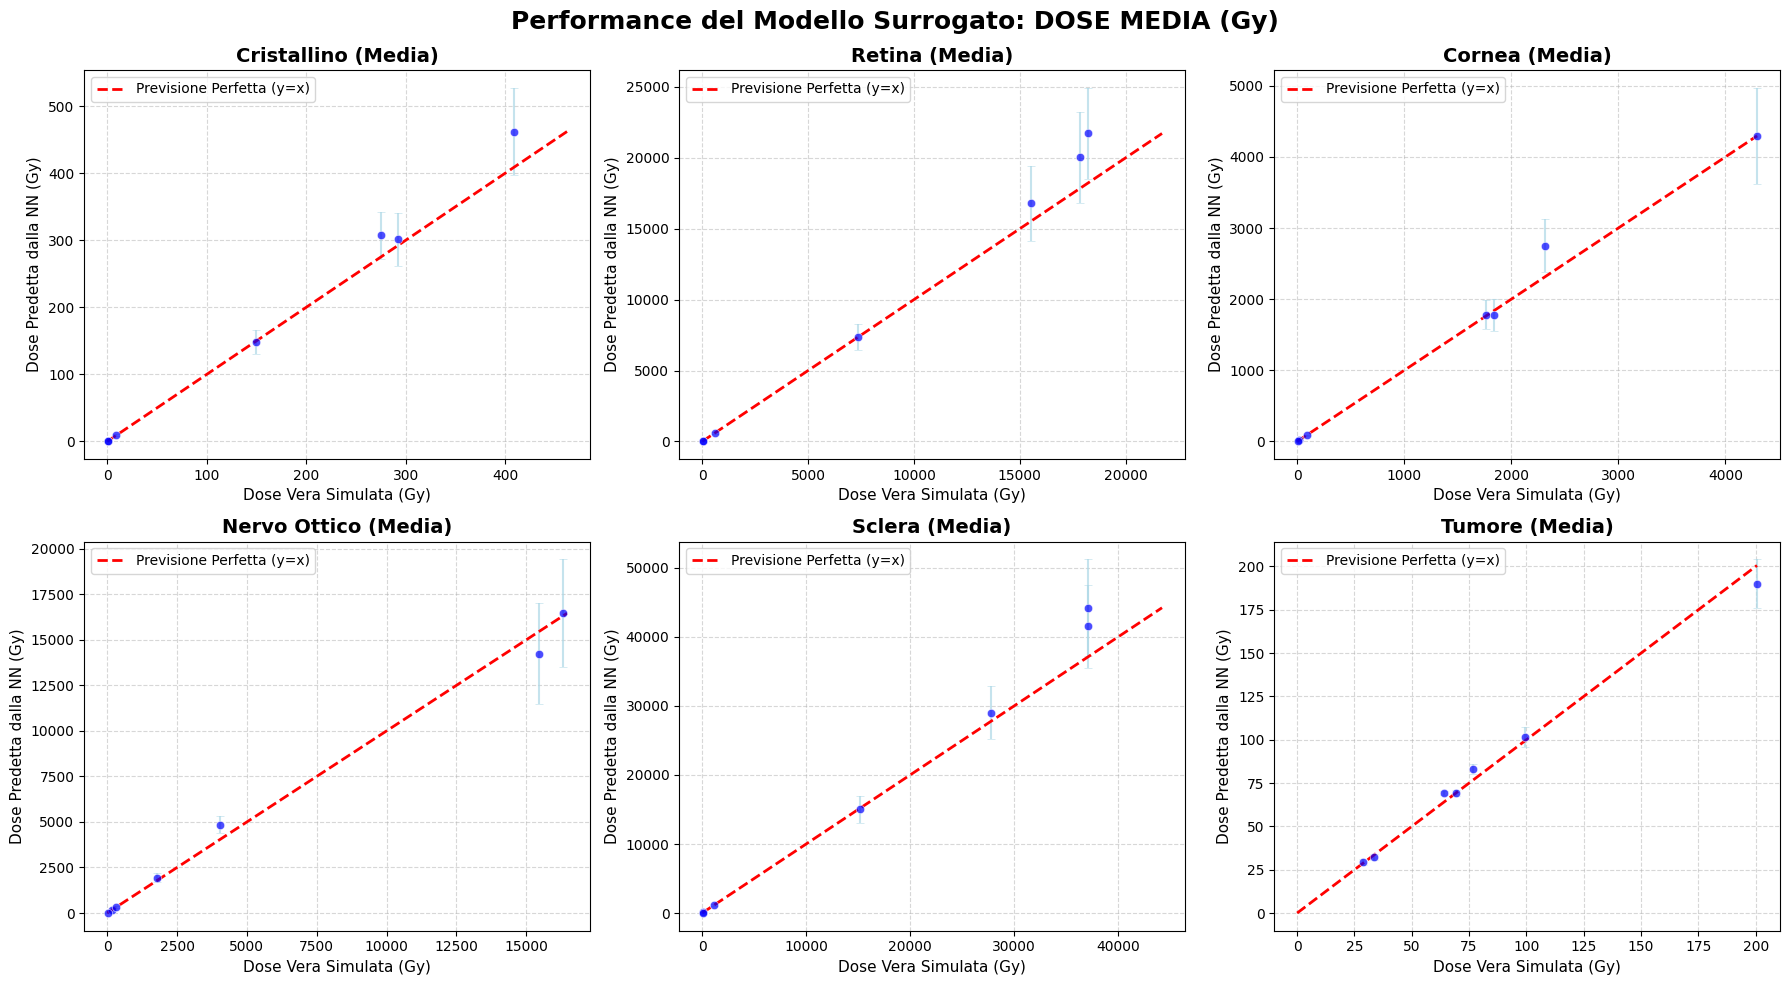

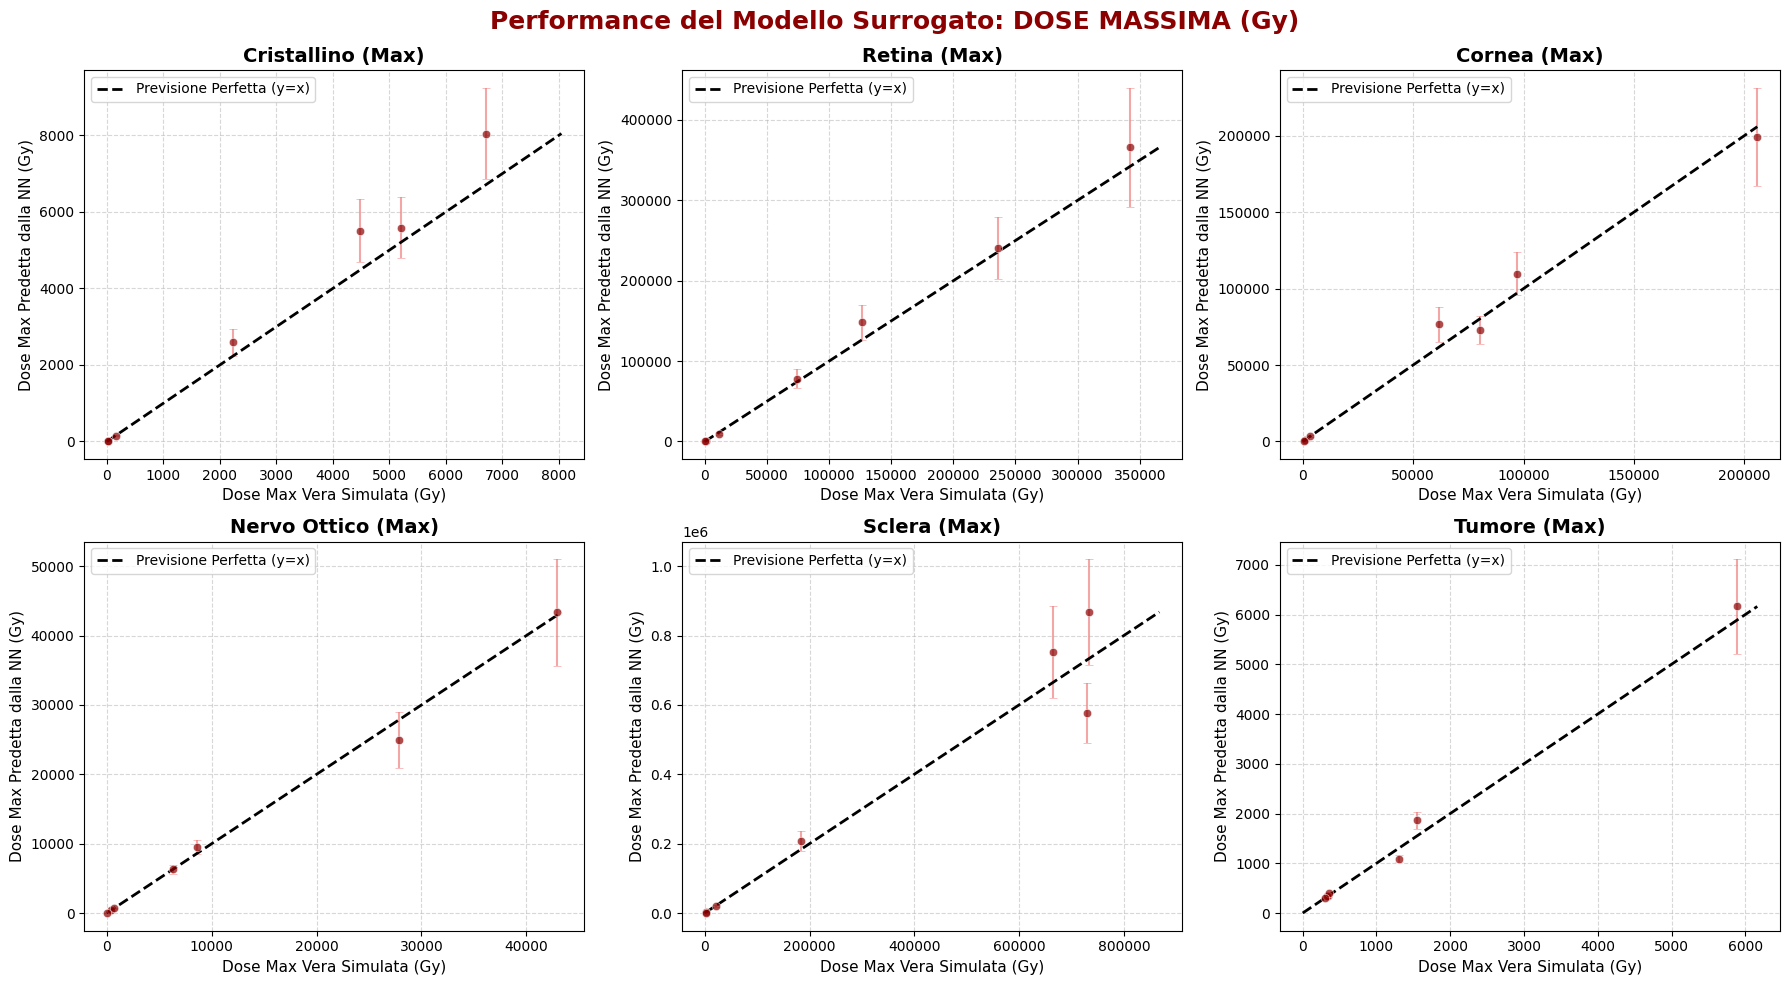

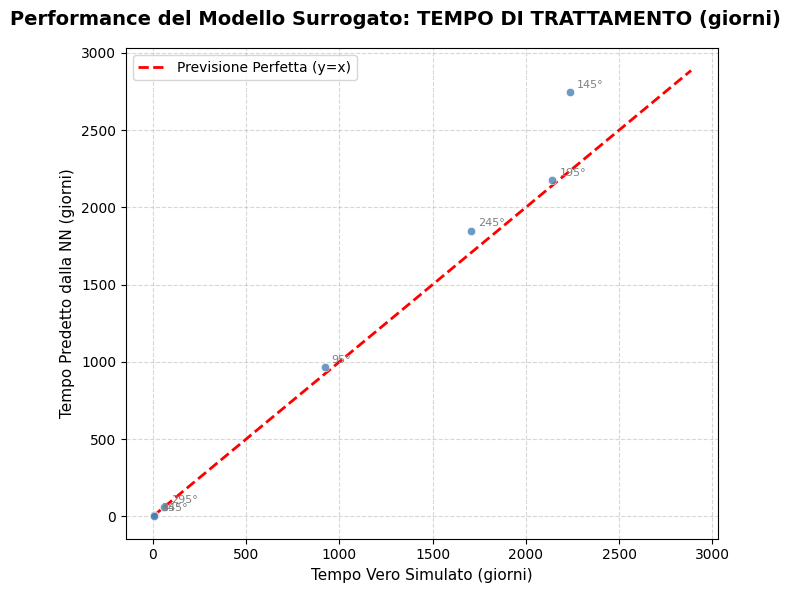

Grafico tempo salvato come 'scatter_plot_tempo_test_set.png'


In [13]:
# Nomi degli organi
organi = ["Cristallino", "Retina", "Cornea", "Nervo Ottico", "Sclera", "Tumore"]

print("\nGenerazione dei grafici di valutazione del Test Set in corso...")

# ==========================================
# GRAFICO 1: DOSE MEDIA
# ==========================================
fig_med, axes_med = plt.subplots(2, 3, figsize=(18, 10))
fig_med.suptitle("Performance del Modello Surrogato: DOSE MEDIA (Gy)", fontsize=18, fontweight='bold')
axes_med = axes_med.flatten()

for i, organo in enumerate(organi):
    # La colonna 0 è il tempo. Ogni organo ha 3 colonne (Media, Std, Max).
    # L'indice della Dose Media è 1 + (i * 3)
    idx_media = 1 + (i * 3)

    dosi_vere = y_test_reale[:, idx_media]
    dosi_predette = test_pred_reale[:, idx_media]

    ax = axes_med[i]

    # Scatter plot
    # Scatter plot con barre d'errore (Incertezza Epistemica)
    ax.errorbar(dosi_vere, dosi_predette, yerr=test_pred_std[:, idx_media],
                fmt='o', color='blue', ecolor='lightblue', elinewidth=1.5,
                capsize=3, alpha=0.7, markeredgecolor='white', markeredgewidth=0.5)

    # Bisettrice (Previsione Perfetta y = x)
    min_val = min(0.0, min(dosi_vere.min(), dosi_predette.min()))
    max_val = max(dosi_vere.max(), dosi_predette.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Previsione Perfetta (y=x)')

    # Formattazione
    ax.set_title(f'{organo} (Media)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Dose Vera Simulata (Gy)', fontsize=11)
    ax.set_ylabel('Dose Predetta dalla NN (Gy)', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
fig_med.subplots_adjust(top=0.92) # Lascia spazio per il titolo globale
plt.savefig('scatter_plot_media_test_set.png', dpi=300)

# ==========================================
# GRAFICO 2: DOSE MASSIMA (HOTSPOT)
# ==========================================
fig_max, axes_max = plt.subplots(2, 3, figsize=(18, 10))
fig_max.suptitle("Performance del Modello Surrogato: DOSE MASSIMA (Gy)", fontsize=18, fontweight='bold', color='darkred')
axes_max = axes_max.flatten()

for i, organo in enumerate(organi):
    # L'indice della Dose Massima è 1 + (i * 3) + 2
    idx_max = 1 + (i * 3) + 2

    dosi_vere_max = y_test_reale[:, idx_max]
    dosi_predette_max = test_pred_reale[:, idx_max]

    ax = axes_max[i]

    # Scatter plot (usiamo il rosso per i massimi per distinguerli visivamente)
    # Scatter plot con barre d'errore (Incertezza Epistemica)
    ax.errorbar(dosi_vere_max, dosi_predette_max, yerr=test_pred_std[:, idx_max],
                fmt='o', color='darkred', ecolor='lightcoral', elinewidth=1.5,
                capsize=3, alpha=0.7, markeredgecolor='white', markeredgewidth=0.5)

    # Bisettrice
    min_val = min(0.0, min(dosi_vere_max.min(), dosi_predette_max.min()))
    max_val = max(dosi_vere_max.max(), dosi_predette_max.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Previsione Perfetta (y=x)')

    # Formattazione
    ax.set_title(f'{organo} (Max)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Dose Max Vera Simulata (Gy)', fontsize=11)
    ax.set_ylabel('Dose Max Predetta dalla NN (Gy)', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
fig_max.subplots_adjust(top=0.92)
plt.savefig('scatter_plot_max_test_set.png', dpi=300)

print("Grafici riassuntivi salvati con successo come 'scatter_plot_media_test_set.png' e 'scatter_plot_max_test_set.png'!")

# Mostra i grafici a schermo
plt.show()

fig_t, ax_t = plt.subplots(figsize=(7, 6))
fig_t.suptitle("Performance del Modello Surrogato: TEMPO DI TRATTAMENTO (giorni)",
               fontsize=14, fontweight='bold')

tempo_vero = y_test_reale[:, 0]
tempo_pred = test_pred_reale[:, 0]
tempo_pred = np.maximum(0.0, tempo_pred)

ax_t.scatter(tempo_vero, tempo_pred, alpha=0.8, color='steelblue',
             edgecolors='white', linewidth=0.5, zorder=3)

min_t = min(0.0, tempo_vero.min(), tempo_pred.min())
max_t = max(tempo_vero.max(), tempo_pred.max()) * 1.05
ax_t.plot([min_t, max_t], [min_t, max_t], 'r--', linewidth=2, label='Previsione Perfetta (y=x)')

sin_t     = X_test[:, 0]
cos_t     = X_test[:, 1]
theta_deg = (np.degrees(np.arctan2(sin_t, cos_t)) + 360) % 360
for j in range(len(tempo_vero)):
    ax_t.annotate(f"{int(round(theta_deg[j]))}°",
                  (tempo_vero[j], tempo_pred[j]),
                  textcoords="offset points", xytext=(5, 3), fontsize=8, color='gray')

ax_t.set_xlabel('Tempo Vero Simulato (giorni)', fontsize=11)
ax_t.set_ylabel('Tempo Predetto dalla NN (giorni)', fontsize=11)
ax_t.grid(True, linestyle='--', alpha=0.5)
ax_t.legend()

plt.tight_layout()
plt.savefig('scatter_plot_tempo_test_set.png', dpi=300)
plt.show()
print("Grafico tempo salvato come 'scatter_plot_tempo_test_set.png'")

$\textbf{5.4 Esame finale dei risultati dell'algoritmo}$

In questa sezione vengono controllati i risultati per concludere la task 1. In particolare viene impostato il modello in fase di validazione sul test set. In questo caso dunque sono tenuti spenti tutti i motori matematici per il tracciamento dei gradienti e per i calcoli, inoltre è spento anche il dropout poiché ora si ha necessità di sfruttare tutti i neuroni della NN per vedere se essa riesce a fare predizioni buone su un dataset che finora non ha mai visto. Inoltre, viene calcolata la metrica MAE, o più propriamente il $\textbf{MAPE}$ (Mean Absolute Percentage Error) definito come:

\begin{equation*}
\text{MAPE} = \left\lvert \frac{D_{\text{pred}}-D_{\text{reale}}}{D_{\text{reale}}} \right\rvert \times 100 
\end{equation*}

Il calcolo di questa metrica permette di stimare la gravità degli errori di predizione della rete neurale. 

              TABELLA VALUTAZIONE METRICHE TEST SET             
                 Feature        MAE  MAPE (%)
          Tempo (giorni)   104.8692    8.7483
Cristallino - Media (Gy)    13.8888    8.1601
  Cristallino - Std (Gy)     0.3691   31.0017
  Cristallino - Max (Gy)   448.2862   12.4888
     Retina - Media (Gy)   998.8365    7.7525
       Retina - Std (Gy)     5.1729   28.2384
       Retina - Max (Gy)  8041.7476    8.7816
     Cornea - Media (Gy)    73.4811    5.8330
       Cornea - Std (Gy)     3.4920   20.0312
       Cornea - Max (Gy)  5967.6616   15.0827
  Nervo Opt - Media (Gy)   336.6325    8.5972
    Nervo Opt - Std (Gy)    46.5295   27.0571
    Nervo Opt - Max (Gy)   624.8920    6.4073
     Sclera - Media (Gy)  1857.4932    6.7275
       Sclera - Std (Gy)     7.1571   28.9998
       Sclera - Max (Gy) 57454.5391   15.4680
     Tumore - Media (Gy)     3.7251    4.2091
       Tumore - Std (Gy)     0.4999   29.9378
       Tumore - Max (Gy)   122.9041    8.4698
MAE Medio Globa

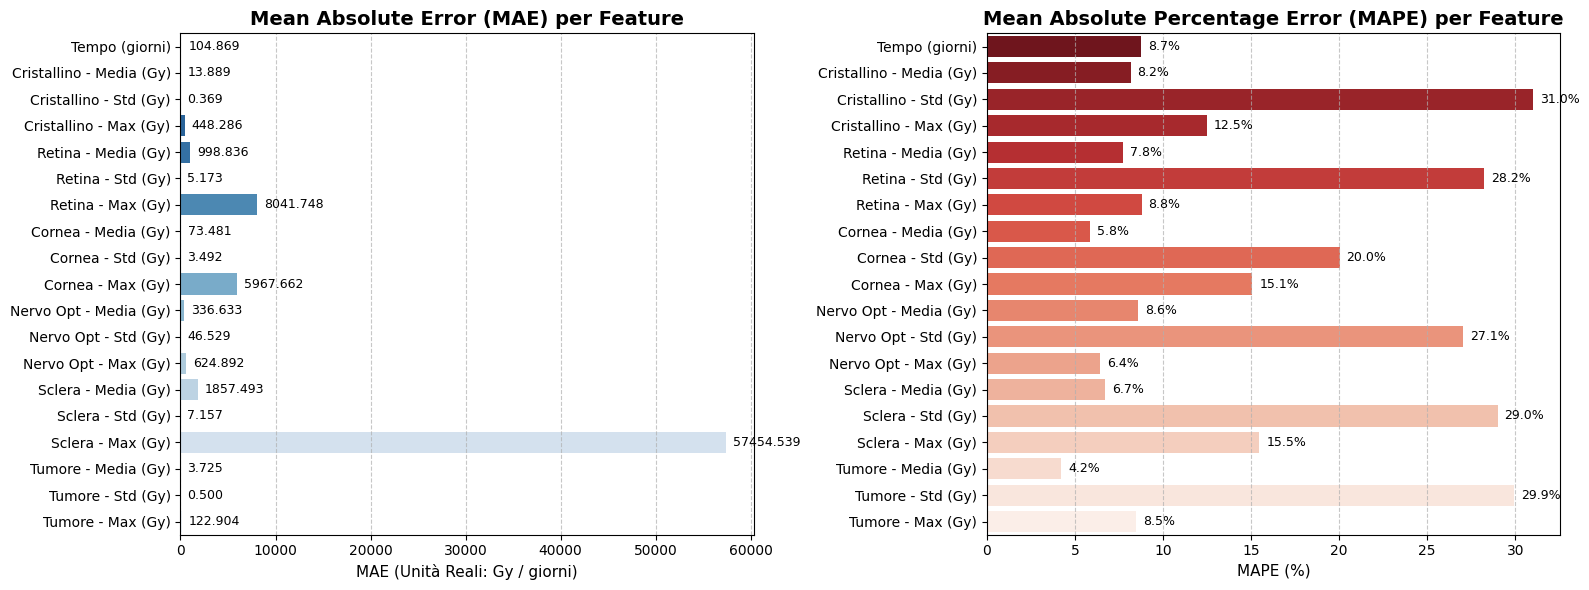

In [ ]:


# ==============================================================================
# 1. CALCOLO METRICHE (MAE e MAPE) IN SCALA REALE
# ==============================================================================

# Definiamo le etichette per i 19 output per una lettura immediata
nomi_output = [
    "Tempo (giorni)",
    "Cristallino - Media (Gy)", "Cristallino - Std (Gy)", "Cristallino - Max (Gy)",
    "Retina - Media (Gy)",      "Retina - Std (Gy)",      "Retina - Max (Gy)",
    "Cornea - Media (Gy)",      "Cornea - Std (Gy)",      "Cornea - Max (Gy)",
    "Nervo Opt - Media (Gy)",   "Nervo Opt - Std (Gy)",   "Nervo Opt - Max (Gy)",
    "Sclera - Media (Gy)",      "Sclera - Std (Gy)",      "Sclera - Max (Gy)",
    "Tumore - Media (Gy)",      "Tumore - Std (Gy)",      "Tumore - Max (Gy)"
]

# Calcolo MAE e MAPE globale e per feature
mae_per_feature = mean_absolute_error(y_test_reale, test_pred_reale, multioutput='raw_values')
mape_per_feature = mean_absolute_percentage_error(y_test_reale, test_pred_reale, multioutput='raw_values') * 100

# Creazione di un DataFrame riassuntivo
df_metriche = pd.DataFrame({
    'Feature': nomi_output,
    'MAE': mae_per_feature,
    'MAPE (%)': mape_per_feature
})

# Stampa tabella in console
print("="*65)
print("              TABELLA VALUTAZIONE METRICHE TEST SET             ")
print("="*65)
print(df_metriche.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("="*65)
print(f"MAE Medio Globale:  {np.mean(mae_per_feature):.4f}")
print(f"MAPE Medio Globale: {np.mean(mape_per_feature):.2f}%")
print("="*65)


# ==============================================================================
# 2. GRAFICI A BARRE PER MAE E MAPE
# ==============================================================================

plt.figure(figsize=(16, 6))

# --- Grafico 1: MAE ---
plt.subplot(1, 2, 1)
ax1 = sns.barplot(data=df_metriche, x='MAE', y='Feature', hue='Feature', palette='Blues_r', legend=False)
plt.title('Mean Absolute Error (MAE) per Feature', fontsize=14, fontweight='bold')
plt.xlabel('MAE (Unità Reali: Gy / giorni)', fontsize=11)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Aggiunge i valori sulle barre
for p in ax1.patches:
    width = p.get_width()
    ax1.annotate(f'{width:.3f}', (width, p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)

# --- Grafico 2: MAPE ---
plt.subplot(1, 2, 2)
ax2 = sns.barplot(data=df_metriche, x='MAPE (%)', y='Feature', hue='Feature', palette='Reds_r', legend=False)
plt.title('Mean Absolute Percentage Error (MAPE) per Feature', fontsize=14, fontweight='bold')
plt.xlabel('MAPE (%)', fontsize=11)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Aggiunge i valori sulle barre
for p in ax2.patches:
    width = p.get_width()
    ax2.annotate(f'{width:.1f}%', (width, p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
# METRICHE QUANTITATIVE SUL TEST SET

from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)


# -------------------------------------------------------------------------
# 1. Predizione deterministica
# -------------------------------------------------------------------------

modello.eval()

with torch.no_grad():
    pred_scaled = modello(X_test_t).cpu().numpy()


# -------------------------------------------------------------------------
# 2. Inversione completa del preprocessing
#
# spazio standardizzato -> spazio log1p -> spazio fisico
# -------------------------------------------------------------------------

pred_log = scaler_y.inverse_transform(pred_scaled)

target_log = scaler_y.inverse_transform(
    y_test_t.cpu().numpy()
)

test_pred_reale = np.expm1(pred_log)
y_test_reale = np.expm1(target_log)


# -------------------------------------------------------------------------
# 3. Controlli preliminari
# -------------------------------------------------------------------------

if y_test_reale.shape != test_pred_reale.shape:
    raise ValueError(
        f"Shape incompatibili: target {y_test_reale.shape}, "
        f"predizioni {test_pred_reale.shape}."
    )

if y_test_reale.ndim != 2:
    raise ValueError(
        f"Gli array devono essere bidimensionali. "
        f"Shape trovata: {y_test_reale.shape}."
    )

N_OUTPUT = y_test_reale.shape[1]

if N_OUTPUT != 19:
    raise ValueError(
        f"Erano attesi 19 output, ma ne sono stati trovati "
        f"{N_OUTPUT}."
    )

if len(y_test_reale) < 2:
    raise ValueError(
        "Il test set deve contenere almeno due campioni."
    )

if not np.all(np.isfinite(y_test_reale)):
    raise ValueError(
        "I target contengono valori NaN o infiniti."
    )

if not np.all(np.isfinite(test_pred_reale)):
    raise ValueError(
        "Le predizioni contengono valori NaN o infiniti."
    )


# -------------------------------------------------------------------------
# 4. Nomi e unità dei 19 output
# -------------------------------------------------------------------------

nomi_output = [
    "Tempo",
    "Crist_media",
    "Crist_std",
    "Crist_max",
    "Ret_media",
    "Ret_std",
    "Ret_max",
    "Corn_media",
    "Corn_std",
    "Corn_max",
    "Nervo_media",
    "Nervo_std",
    "Nervo_max",
    "Sclera_media",
    "Sclera_std",
    "Sclera_max",
    "Tumor_media",
    "Tumor_std",
    "Tumor_max"
]

unita_output = [
    "giorni" if indice == 0 else "Gy"
    for indice in range(N_OUTPUT)
]


# -------------------------------------------------------------------------
# 5. Calcolo delle metriche per ciascun output
# -------------------------------------------------------------------------

risultati_metriche = []

for indice, nome in enumerate(nomi_output):

    y_true = y_test_reale[:, indice]
    y_pred = test_pred_reale[:, indice]

    # Residuo con segno:
    # positivo = sovrastima
    # negativo = sottostima
    errore = y_pred - y_true

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        np.mean(
            errore**2
        )
    )

    bias = np.mean(
        errore
    )

    std_target = np.std(
        y_true,
        ddof=1
    )

    minimo_target = np.min(
        y_true
    )

    massimo_target = np.max(
        y_true
    )

    # R² non è definito se il target è sostanzialmente costante
    if np.isclose(
        std_target,
        0.0,
        atol=1e-12,
        rtol=1e-8
    ):
        r2 = np.nan

    else:
        r2 = r2_score(
            y_true,
            y_pred
        )

    risultati_metriche.append({
        "Output": nome,
        "Unità": unita_output[indice],
        "MAE": mae,
        "RMSE": rmse,
        "Bias": bias,
        "R²": r2,
        "Std target": std_target,
        "Min target": minimo_target,
        "Max target": massimo_target
    })


# -------------------------------------------------------------------------
# 6. Tabella finale
# -------------------------------------------------------------------------

df_metriche_test = pd.DataFrame(
    risultati_metriche
)


# -------------------------------------------------------------------------
# 7. Controllo numerico di coerenza tra RMSE, varianza e R²
#
# R² = 1 - n * RMSE² / [(n - 1) * s_y²]
#
# dove s_y è calcolata con ddof=1.
# -------------------------------------------------------------------------

n_campioni = len(y_test_reale)

for _, risultato in df_metriche_test.iterrows():

    r2 = risultato["R²"]

    if not np.isfinite(r2):
        continue

    rmse = risultato["RMSE"]
    std_target = risultato["Std target"]

    r2_ricostruito = 1.0 - (
        n_campioni * rmse**2
    ) / (
        (n_campioni - 1) * std_target**2
    )

    if not np.isclose(
        r2,
        r2_ricostruito,
        atol=1e-8,
        rtol=1e-6
    ):
        raise RuntimeError(
            f"Controllo di coerenza fallito per "
            f"{risultato['Output']}: "
            f"R² = {r2:.8f}, "
            f"R² ricostruito = {r2_ricostruito:.8f}."
        )


# -------------------------------------------------------------------------
# 8. Visualizzazione
# -------------------------------------------------------------------------

print(
    "Metriche sul test set — "
    "predizione deterministica nelle unità fisiche"
)

print(
    f"Campioni di test: {n_campioni}"
)

display(
    df_metriche_test.style
    .hide(axis="index")
    .format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "Bias": "{:+.4f}",
        "R²": lambda valore: (
            f"{valore:.4f}"
            if np.isfinite(valore)
            else "n.d."
        ),
        "Std target": "{:.4f}",
        "Min target": "{:.4f}",
        "Max target": "{:.4f}"
    })
)


# -------------------------------------------------------------------------
# 9. Riepilogo dei coefficienti R²
# -------------------------------------------------------------------------

numero_r2_positivi = int(
    np.sum(
        df_metriche_test["R²"] >= 0.0
    )
)

numero_r2_negativi = int(
    np.sum(
        df_metriche_test["R²"] < 0.0
    )
)

numero_r2_non_definiti = int(
    df_metriche_test["R²"]
    .isna()
    .sum()
)

print()
print("Riepilogo R²")

print(
    f"  Output con R² positivo o nullo: "
    f"{numero_r2_positivi}/{N_OUTPUT}"
)

print(
    f"  Output con R² negativo:         "
    f"{numero_r2_negativi}/{N_OUTPUT}"
)

print(
    f"  Output con R² non definito:     "
    f"{numero_r2_non_definiti}/{N_OUTPUT}"
)

Metriche sul test set — predizione deterministica nelle unità fisiche
Campioni di test: 7


Output,Unità,MAE,RMSE,Bias,R²,Std target,Min target,Max target
Tempo,giorni,49.7627,85.9293,+49.7348,0.9917,1016.2009,6.6560,2237.2561
Crist_media,Gy,8.5973,13.3004,+8.1736,0.9925,166.3934,0.8206,408.7604
Crist_std,Gy,0.4173,0.7375,-0.1400,0.9899,7.9357,0.0286,20.4454
Crist_max,Gy,368.2570,624.7063,+367.4673,0.9413,2784.2417,12.9703,6703.9941
Ret_media,Gy,405.0867,665.7817,+404.8610,0.9929,8537.1680,34.7106,18220.9102
Ret_std,Gy,4.1306,6.0377,+3.4196,0.9326,25.1138,0.1410,53.4780
Ret_max,Gy,6621.3911,11565.2402,+966.4166,0.9911,132191.0938,435.2447,341818.0625
Corn_media,Gy,75.9980,145.8848,+73.1141,0.9901,1585.1738,7.0793,4293.7007
Corn_std,Gy,3.2737,5.0376,+1.7762,0.9148,18.6402,0.1267,43.1133
Corn_max,Gy,4412.2026,7209.1382,+4133.8442,0.9890,74379.4922,436.2703,205835.3281



Riepilogo R²
  Output con R² positivo o nullo: 19/19
  Output con R² negativo:         0/19
  Output con R² non definito:     0/19


In questa e nella prossima sezione si osservano le performance dell'addestramento e della validazione, in particolare si valuta l'andamento delle funzioni di train loss e di validation loss durante le due diverse fasi. Questo check serve per verificare la bontà dell'algoritmo e per rendere conto della presenza o meno di possibili overfitting 

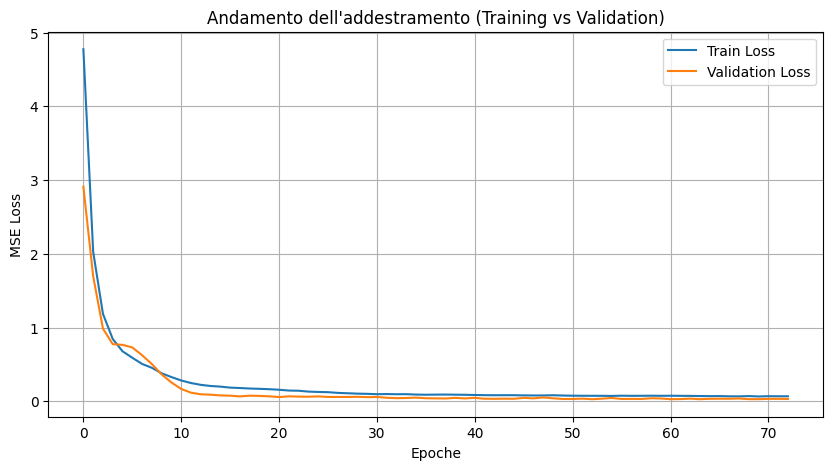

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoche')
plt.ylabel('MSE Loss')
plt.title('Andamento dell\'addestramento (Training vs Validation)')
plt.legend()
plt.grid(True)
plt.savefig('andamento_training.png') # Salva il grafico
plt.show()


Grafico della loss salvato come 'learning_curves.png'


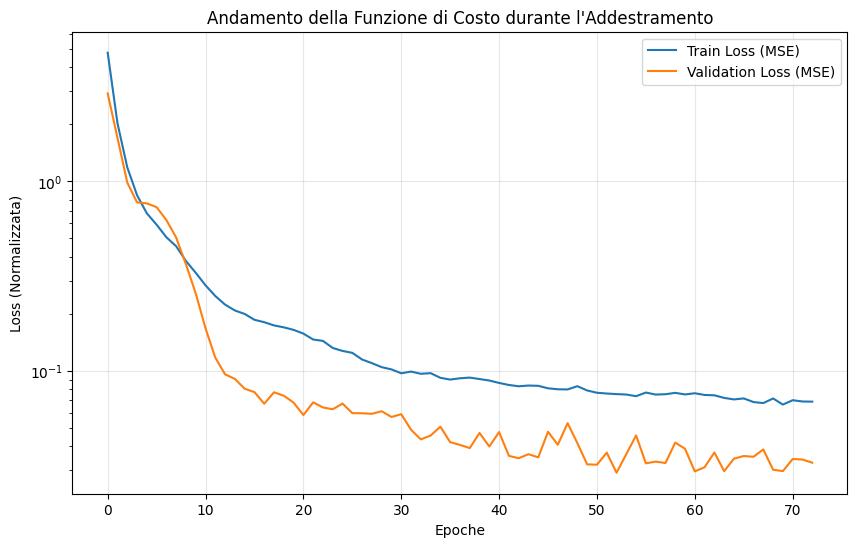

In [ ]:
# --- PLOT DELLE LEARNING CURVES ---
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss (MSE)')
plt.plot(val_losses, label='Validation Loss (MSE)')
plt.title('Andamento della Funzione di Costo durante l\'Addestramento')
plt.xlabel('Epoche')
plt.ylabel('Loss (Normalizzata)')
plt.yscale('log') # La scala logaritmica aiuta a vedere meglio la discesa finale
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('learning_curves.png', dpi=300)
print("\nGrafico della loss salvato come 'learning_curves.png'")

# 6. Task 2: Ottimizzazione della posizione della placca 

Viene ora sviluppata e anallizzata la task 2 del progetto proposto. La task prevede di ottimizzare la posizione della placca di $^{106}$Ru attraverso l'analisi delle posizioni fornite in partenza da parte del modello surrogato sviluppato. Tale analisi è stata articolata in più fasi:
1. $\textbf{Definizione dello spazio di ricerca}$: le simulazioni fornite riproducono il movimento della placca brachiterapica su tutta la circonferenza dell'occhio con spostamenti angolari di $\Delta\theta = 5^\circ$ nel range [0 $^\circ$, 355 $^\circ$]; quindi viene creato un array contenente i valori delgi angoli opportunamente convertiti in radianti per usare le funzioni goniometriche.
2. $\textbf{Inferenza e Post-processing}$: le feature vettoriali sono state scalate e fornite al modello in modalità `torch.no_grad()`; gli output predetti dal modello in modalità di valutazione sono stati poi convertiti alla scala fisica di partenza per una maggiore leggibilità e facilità interpretativa: la conversione è stata eseguita invertendo la trasformazione logaritmica introdotta dallo scaler.
3. $\textbf{Definizione della regione ammissibile}$: l'obiettivo finale è quello di trovare la configurazione ottimale che rispetta i vincoli clinici imposti in partenza; a tale scopo sono state sviluppate delle maschere booleane deputate alla gestione di queste soglie cliniche. Tali soglie definiscono inoltre la regione fisica del problema: una configurazione angolare è ritenuta ammissibile se soddisfa le soglie di tolleranza radiobiologica sugli Organi A Rischio (OAR) e la durata massima del trattamento ($T < 7\text{ giorni}$).
4. $\textbf{Definizione della posizione ottimale}$: Una volta filtrate, la miglior configurazione è definita come quella che non solo rispetta i vincoli clinici ma minimizza il rischio cumulativo del picco di dose sugli OAR. Questa quantità è definita come:
\begin{equation*}
f(\theta) = \sum_{k \in \text{OAR}} \text{Dose}_{\max, k}(\theta)
\end{equation*}


In [21]:
# ==============================================================================
# TASK 2: OTTIMIZZAZIONE DELLA POSIZIONE DELLA PLACCA (INFERENCE & FILTERING)
# ==============================================================================
print("\n" + "="*85)
print("   TASK 2: RICERCA DELLA POSIZIONE OTTIMALE (VINCOLI CLINICI)")
print("="*85)

# 1. Creazione dello Spazio di Ricerca (scatti di 5 gradi)
angoli_gradi = np.arange(0, 360, 5)
angoli_rad = np.radians(angoli_gradi)

# Calcolo dinamico della quantità di angoli esplorati (saranno 72)
numero_angoli = len(angoli_gradi)

# Ricostruzione delle 5 features di input per il modello (sin_t, cos_t, sin_p, cos_p, raggio)
# Utilizziamo phi=0 e prendiamo il raggio medio calcolato dal dataset X originario
phi_rad = 0.0
raggio_medio = X[:, 4].mean()

X_opt = np.zeros((numero_angoli, 5))
X_opt[:, 0] = np.sin(angoli_rad)
X_opt[:, 1] = np.cos(angoli_rad)
X_opt[:, 2] = np.sin(phi_rad)
X_opt[:, 3] = np.cos(phi_rad)
X_opt[:, 4] = raggio_medio

# 2. Forward Pass attraverso il Modello Surrogato
X_opt_scaled = scaler_X.transform(X_opt).astype('float32')
X_opt_t = torch.tensor(X_opt_scaled).to(device)

modello.eval()
with torch.no_grad():
    pred_scaled_opt = modello(X_opt_t).cpu().numpy()

# Descalatura e inversione del logaritmo (Expm1)
pred_log_opt = scaler_y.inverse_transform(pred_scaled_opt)
pred_reale_opt = np.expm1(pred_log_opt)

# 3. Estrazione delle Metriche per l'Ottimizzazione
tempo_opt        = pred_reale_opt[:, MAPPA_COLONNE['tempo']]
crist_media_opt  = pred_reale_opt[:, MAPPA_COLONNE['crist_media']]
retina_media_opt = pred_reale_opt[:, MAPPA_COLONNE['retina_media']]
cornea_media_opt = pred_reale_opt[:, MAPPA_COLONNE['cornea_media']]
nervo_media_opt  = pred_reale_opt[:, MAPPA_COLONNE['nervo_media']]
sclera_media_opt = pred_reale_opt[:, MAPPA_COLONNE['sclera_media']]

crist_max_opt  = pred_reale_opt[:, MAPPA_COLONNE['crist_max']]
retina_max_opt = pred_reale_opt[:, MAPPA_COLONNE['retina_max']]
cornea_max_opt = pred_reale_opt[:, MAPPA_COLONNE['cornea_max']]
nervo_max_opt  = pred_reale_opt[:, MAPPA_COLONNE['nervo_max']]
sclera_max_opt = pred_reale_opt[:, MAPPA_COLONNE['sclera_max']]

somma_max_oar = crist_max_opt + retina_max_opt + cornea_max_opt + nervo_max_opt + sclera_max_opt

# 4. Applicazione dei Vincoli Clinici (Maschera Booleana)
maschera_vincoli = (
    (tempo_opt < 7.0) &
    (crist_media_opt < 5.0) &
    (retina_media_opt < 45.0) &
    (cornea_media_opt < 50.0) &
    (nervo_media_opt < 55.0) &
    (sclera_media_opt < 100.0)
)

angoli_validi = angoli_gradi[maschera_vincoli]


print("\n[ REPORT ANGOLI SCARTATI ]")
for i, angolo in enumerate(angoli_gradi):
    if not maschera_vincoli[i]: # Se l'angolo non ha superato il filtro
        motivi = []
        if tempo_opt[i] >= 7.0:        motivi.append(f"Tempo ({tempo_opt[i]:.2f}gg >= 7)")
        if crist_media_opt[i] >= 5.0:  motivi.append(f"Cristallino ({crist_media_opt[i]:.2f}Gy >= 5)")
        if retina_media_opt[i] >= 45.0:motivi.append(f"Retina ({retina_media_opt[i]:.2f}Gy >= 45)")
        if cornea_media_opt[i] >= 50.0:motivi.append(f"Cornea ({cornea_media_opt[i]:.2f}Gy >= 50)")
        if nervo_media_opt[i] >= 55.0: motivi.append(f"Nervo Ott. ({nervo_media_opt[i]:.2f}Gy >= 55)")
        if sclera_media_opt[i] >= 100.0:motivi.append(f"Sclera ({sclera_media_opt[i]:.2f}Gy >= 100)")

print("-" * 85)

# 5. Valutazione e Selezione
if len(angoli_validi) == 0:
    print("\n[!] ATTENZIONE: Nessun angolo soddisfa tutti i limiti clinici imposti.")
else:
    print(f"\nSono stati trovati {len(angoli_validi)} angoli che rispettano tutti i limiti clinici.")

    df_validi = pd.DataFrame({
        'Angolo (°)': angoli_validi,
        'Tempo (gg)': tempo_opt[maschera_vincoli],
        'Crist. Med (Gy)': crist_media_opt[maschera_vincoli],
        'Retina Med (Gy)': retina_media_opt[maschera_vincoli],
        'Cornea Med (Gy)': cornea_media_opt[maschera_vincoli],
        'Nervo Med (Gy)': nervo_media_opt[maschera_vincoli],
        'Sclera Med (Gy)': sclera_media_opt[maschera_vincoli],
        'Somma Dosi Max OAR (Gy)': somma_max_oar[maschera_vincoli]
    })

    df_ordinato = df_validi.sort_values(by='Somma Dosi Max OAR (Gy)').reset_index(drop=True)
    migliore_angolo = df_ordinato.iloc[0]

    print("\n" + "*"*85)
    print(f"   MIGLIOR CONFIGURAZIONE TROVATA: {int(migliore_angolo['Angolo (°)'])}°")
    print("*"*85)
    print(f"Tempo di trattamento : {migliore_angolo['Tempo (gg)']:.2f} giorni")
    print(f"Dose Media Cristallino : {migliore_angolo['Crist. Med (Gy)']:.2f} Gy (Limite: 5 Gy)")
    print(f"Dose Media Retina    : {migliore_angolo['Retina Med (Gy)']:.2f} Gy (Limite: 45 Gy)")
    print(f"Dose Media Cornea    : {migliore_angolo['Cornea Med (Gy)']:.2f} Gy (Limite: 50 Gy)")
    print(f"Dose Media Nervo Ott.  : {migliore_angolo['Nervo Med (Gy)']:.2f} Gy (Limite: 55 Gy)")
    print(f"Dose Media Sclera    : {migliore_angolo['Sclera Med (Gy)']:.2f} Gy (Limite: 100 Gy)")
    print(f"\n=> Somma Dosi Max OAR: {migliore_angolo['Somma Dosi Max OAR (Gy)']:.2f} Gy")
    print("*"*85)

    print("\nEcco le migliori configurazioni valide (per Sum_Max_OAR minore):")
    print(df_ordinato.head(14).to_string(index=False))


   TASK 2: RICERCA DELLA POSIZIONE OTTIMALE (VINCOLI CLINICI)

[ REPORT ANGOLI SCARTATI ]
-------------------------------------------------------------------------------------

Sono stati trovati 8 angoli che rispettano tutti i limiti clinici.

*************************************************************************************
   MIGLIOR CONFIGURAZIONE TROVATA: 0°
*************************************************************************************
Tempo di trattamento : 6.38 giorni
Dose Media Cristallino : 0.56 Gy (Limite: 5 Gy)
Dose Media Retina    : 27.95 Gy (Limite: 45 Gy)
Dose Media Cornea    : 2.34 Gy (Limite: 50 Gy)
Dose Media Nervo Ott.  : 9.09 Gy (Limite: 55 Gy)
Dose Media Sclera    : 48.38 Gy (Limite: 100 Gy)

=> Somma Dosi Max OAR: 1054.32 Gy
*************************************************************************************

Ecco le migliori configurazioni valide (per Sum_Max_OAR minore):
 Angolo (°)  Tempo (gg)  Crist. Med (Gy)  Retina Med (Gy)  Cornea Med (Gy)  Nervo

In [ ]:
# ==============================================================================
# TASK 2.1: OTTIMIZZAZIONE POSIZIONE PLACCA (DIFFERENTIABLE PROGRAMMING - MULTI START)
# ==============================================================================


print("\n" + "=" * 85)
print("   TASK 2.1: OTTIMIZZAZIONE POSIZIONE PLACCA (DIFFERENTIABLE PROGRAMMING)")
print("=" * 85)

# 1. Congeliamo i pesi del modello surrogato
modello.eval()
for param in modello.parameters():
    param.requires_grad = False

# 2. Parametri clinici di vincolo
PHI_RAD = 0.0
RAGGIO_MEDIO = float(X[:, 4].mean())

# Pre-convertiamo medie e scale
mean_X = torch.tensor(scaler_X.mean_, dtype=torch.float32, device=device)
scale_X = torch.tensor(scaler_X.scale_, dtype=torch.float32, device=device)
mean_y = torch.tensor(scaler_y.mean_, dtype=torch.float32, device=device)
scale_y = torch.tensor(scaler_y.scale_, dtype=torch.float32, device=device)


# 3. DEFINIZIONE DELLA LOSS CLINICA (Con vincoli/penalità)
def calcola_loss_clinica(pred_reale):
    tempo = pred_reale[0, 0]

    crist_med = pred_reale[0, 1]
    retina_med = pred_reale[0, 4]
    cornea_med = pred_reale[0, 7]
    nervo_med = pred_reale[0, 10]
    sclera_med = pred_reale[0, 13]

    somma_max_oar = (
        pred_reale[0, 3]
        + pred_reale[0, 6]
        + pred_reale[0, 9]
        + pred_reale[0, 12]
        + pred_reale[0, 15]
    )

    # Penalità morbide (ReLU): si attivano solo se si supera la soglia clinica
    penalty_tempo = torch.relu(tempo - 7.0) ** 2
    penalty_crist = torch.relu(crist_med - 5.0) ** 2
    penalty_retina = torch.relu(retina_med - 45.0) ** 2
    penalty_cornea = torch.relu(cornea_med - 50.0) ** 2
    penalty_nervo = torch.relu(nervo_med - 55.0) ** 2
    penalty_sclera = torch.relu(sclera_med - 100.0) ** 2

    # Loss totale: Minimizzo la dose max OAR + Penallizzo pesantemente le violazioni
    loss_totale = (
        somma_max_oar
        + 1000.0
        * (
            penalty_tempo
            + penalty_crist
            + penalty_retina
            + penalty_cornea
            + penalty_nervo
            + penalty_sclera
        )
    )

    return loss_totale, somma_max_oar


# --- INIZIO MULTI-START OPTIMIZATION ---
punti_partenza_deg = [0.0, 90.0, 180.0, 270.0]
miglior_loss_assoluta = float('inf')
ottimo_assoluto_deg = None
predizioni_ottime = None

print("Inizio ottimizzazione differenziabile multi-start...")

for start_deg in punti_partenza_deg:
    # Definiamo l'angolo theta di partenza
    theta_param = torch.tensor(
        [np.radians(start_deg)],
        dtype=torch.float32,
        device=device,
        requires_grad=True,
    )
    optimizer_plaque = optim.Adam([theta_param], lr=0.05)

    num_steps = 300
    for step in range(num_steps):
        optimizer_plaque.zero_grad()

        sin_t = torch.sin(theta_param)
        cos_t = torch.cos(theta_param)
        sin_p = torch.tensor(
            [np.sin(PHI_RAD)], dtype=torch.float32, device=device
        )
        cos_p = torch.tensor(
            [np.cos(PHI_RAD)], dtype=torch.float32, device=device
        )
        r_val = torch.tensor(
            [RAGGIO_MEDIO], dtype=torch.float32, device=device
        )

        x_input = (
            torch.cat([sin_t, cos_t, sin_p, cos_p, r_val]).unsqueeze(0).float()
        )
        x_input_scaled = (x_input - mean_X) / scale_X

        # Forward pass
        pred_scaled = modello(x_input_scaled)
        pred_log = (pred_scaled * scale_y) + mean_y
        pred_reale = torch.expm1(pred_log)

        loss, somma_max = calcola_loss_clinica(pred_reale)
        loss.backward()
        optimizer_plaque.step()

    loss_finale = loss.item()
    angolo_trovato = (np.degrees(theta_param.item()) % 360 + 360) % 360

    print(
        f"  └ Start da {start_deg:3.0f}° ➔ Angolo Trovato: {angolo_trovato:6.2f}° | Loss Final: {loss_finale:.4f}"
    )

    if loss_finale < miglior_loss_assoluta:
        miglior_loss_assoluta = loss_finale
        ottimo_assoluto_deg = angolo_trovato
        predizioni_ottime = pred_reale.detach().cpu().numpy()

# 6. Risultato Finale
print("\n" + "*" * 85)
print(
    f" 🏆 MIGLIOR ANGOLO GLOBALE TROVATO (MULTI-START): {ottimo_assoluto_deg:.2f}°"
)
print(f"    Loss Clinica Totale: {miglior_loss_assoluta:.4f}")

# Stampa delle metriche nella posizione ottimale trovata
print("\n[ METRICHE CLINICHE PREDETTE ALL'ANGOLO OTTIMALE ]")
print(f"Tempo di trattamento : {predizioni_ottime[0, 0]:.2f} giorni")
print(f"Dose Media Cristallino : {predizioni_ottime[0, 1]:.2f} Gy")
print(f"Dose Media Retina    : {predizioni_ottime[0, 4]:.2f} Gy")
print(f"Dose Media Cornea    : {predizioni_ottime[0, 7]:.2f} Gy")
print(f"Dose Media Nervo Ott.  : {predizioni_ottime[0, 10]:.2f} Gy")
print(f"Dose Media Sclera    : {predizioni_ottime[0, 13]:.2f} Gy")
print("*" * 85)


   TASK 2: OTTIMIZZAZIONE POSIZIONE PLACCA (DIFFERENTIABLE PROGRAMMING)
Inizio ottimizzazione differenziabile multi-start...
  └ Start da   0° ➔ Angolo Trovato: 359.84° | Loss Final: 1054.2216
  └ Start da  90° ➔ Angolo Trovato:  55.40° | Loss Final: 56732868.0000
  └ Start da 180° ➔ Angolo Trovato: 179.35° | Loss Final: 627365117952.0000
  └ Start da 270° ➔ Angolo Trovato: 307.97° | Loss Final: 57730236.0000

*************************************************************************************
 🏆 MIGLIOR ANGOLO GLOBALE TROVATO (MULTI-START): 359.84°
    Loss Clinica Totale: 1054.2216

[ METRICHE CLINICHE PREDETTE ALL'ANGOLO OTTIMALE ]
Tempo di trattamento : 6.38 giorni
Dose Media Cristallino : 0.56 Gy
Dose Media Retina    : 27.96 Gy
Dose Media Cornea    : 2.34 Gy
Dose Media Nervo Ott.  : 9.01 Gy
Dose Media Sclera    : 48.39 Gy
*************************************************************************************


# 7. Task 3: Ottimizzazione robusta della posizione della placca tramite Monte Carlo Dropout

Nella task 2 che è stata appena discussa in dettaglio l'obiettivo era solo quello di trovare la posizione ottimale. In quest'ultima fase del progetto si vuole anche quantificare il livello di stabilità della soluzione integrando la quantificazione dell'incertezza del modello nel processo di estrazione della configurazione ottimale con il framework, già discusso in precedenza, del Monte Carlo Dropout. Con una sola iterazione infatti si rischia di estrarre configurazioni sub-ottimali (poiché una piccola perturbazione potrebbe rendere la configurazione non ottimale) o sensibili al rumore di modellizzazione. Per rendere stabile la scelta della configurazione trovata dal modello si sceglie di far ripetere le operazioni di estrazione per $N = 1000$ volte. Ad ogni iterazione l'algoritmo segue la seguente logica:
1. $\textbf{Attivazione del modello}$: si imposta il modello in modalità `.train()` per mantenere attivo il dropout con una probabilità $p$; in questo passaggio si pone il modello in modalità `torch.no_grad()` al fine di non far ricalcolare i gradienti mantenendo il codice leggero dal punto di vista delle risorse computazionali.
2. $\textbf{Campionamento della Distribuzione di probabilità a posteriori}$: l'attivazione del dropout rappresenta di fatto l'analisi di N reti neurali leggermente diverse l'una dall'altra prese da una distribuzione $p(\mathbf{W}|D)$ dove $\mathbf{W}$ rappresenta i pesi e D il dataset.
3. $\textbf{Frequenza di Ottimalità e Confidenza}$: per ciascuna interazione vengono ripetute tutte le operazioni già descritte nella task precedente per l'estrazione della posizione migliore della placca. La differenza fondamentale in questo caso è che per ogni interazione viene registrato il risultato finale dell'analisi intermedia in modo che il rislutato definitivo sia definito come la moda della distribuzione dei risultati, cioè il valore che si è ottenuto con maggiore frequenza. Questo approccio permette di quantificare la percentuale di vittorie rispetto al totale delle iterazioni come l'$\textbf{indice di confidenza statistica}$ del piano di trattamento.

In [27]:
# ==============================================================================
# TASK 3: OTTIMIZZAZIONE ROBUSTA TRAMITE MONTE CARLO DROPOUT (1000 ITERAZIONI)
# ==============================================================================
print("\n" + "="*85)
print("   TASK 3: OTTIMIZZAZIONE ROBUSTA (1000 ITERAZIONI)")
print("="*85)

n_iterazioni = 1000
migliori_angoli_storico = []

# 1. Creazione dello Spazio di Ricerca Fisso
angoli_gradi = np.arange(0, 360, 5)
numero_angoli = len(angoli_gradi)
angoli_rad = np.radians(angoli_gradi)
phi_rad = 0.0
raggio_medio = X[:, 4].mean()

X_opt = np.zeros((numero_angoli, 5))
X_opt[:, 0] = np.sin(angoli_rad)
X_opt[:, 1] = np.cos(angoli_rad)
X_opt[:, 2] = np.sin(phi_rad)
X_opt[:, 3] = np.cos(phi_rad)
X_opt[:, 4] = raggio_medio

X_opt_scaled = scaler_X.transform(X_opt).astype('float32')
X_opt_t = torch.tensor(X_opt_scaled).to(device)

# ATTENZIONE: Usiamo .train() per mantenere attivo il Dropout e campionare l'incertezza!
modello.train()

print(f"Esecuzione di {n_iterazioni} simulazioni Monte Carlo per trovare l'ottimo globale...")

# 2. Ciclo di Batch (1000 predizioni)
for i in range(n_iterazioni):
    with torch.no_grad():
        # Ad ogni iterazione il dropout spegne neuroni diversi, creando lievi variazioni
        pred_scaled_opt = modello(X_opt_t).cpu().numpy()

    pred_log_opt = scaler_y.inverse_transform(pred_scaled_opt)
    pred_reale_opt = np.expm1(pred_log_opt)

    # Estrazione Metriche
    tempo_opt        = pred_reale_opt[:, MAPPA_COLONNE['tempo']]
    crist_media_opt  = pred_reale_opt[:, MAPPA_COLONNE['crist_media']]
    retina_media_opt = pred_reale_opt[:, MAPPA_COLONNE['retina_media']]
    cornea_media_opt = pred_reale_opt[:, MAPPA_COLONNE['cornea_media']]
    nervo_media_opt  = pred_reale_opt[:, MAPPA_COLONNE['nervo_media']]
    sclera_media_opt = pred_reale_opt[:, MAPPA_COLONNE['sclera_media']]

    crist_max_opt  = pred_reale_opt[:, MAPPA_COLONNE['crist_max']]
    retina_max_opt = pred_reale_opt[:, MAPPA_COLONNE['retina_max']]
    cornea_max_opt = pred_reale_opt[:, MAPPA_COLONNE['cornea_max']]
    nervo_max_opt  = pred_reale_opt[:, MAPPA_COLONNE['nervo_max']]
    sclera_max_opt = pred_reale_opt[:, MAPPA_COLONNE['sclera_max']]

    somma_max_oar = crist_max_opt + retina_max_opt + cornea_max_opt + nervo_max_opt + sclera_max_opt

    # Applicazione Vincoli
    maschera_vincoli = (
        (tempo_opt < 7.0) &
        (crist_media_opt < 5.0) &
        (retina_media_opt < 45.0) &
        (cornea_media_opt < 50.0) &
        (nervo_media_opt < 55.0) &
        (sclera_media_opt < 100.0)
    )

    angoli_validi = angoli_gradi[maschera_vincoli]
    somma_valida = somma_max_oar[maschera_vincoli]

    # Se c'è almeno un angolo valido in questa specifica iterazione
    if len(angoli_validi) > 0:
        # Trova l'indice dell'angolo con la minor somma delle dosi massime
        idx_migliore = np.argmin(somma_valida)
        miglior_angolo_iterazione = angoli_validi[idx_migliore]
        migliori_angoli_storico.append(miglior_angolo_iterazione)

# 3. Analisi Statistica dei Risultati
conteggio_angoli = collections.Counter(migliori_angoli_storico)

print("\n" + "-"*85)
print(f" RISULTATI FREQUENZA (Su {n_iterazioni} iterazioni)")
print("-"*85)

if len(conteggio_angoli) == 0:
    print("Nessun angolo ha superato i vincoli in nessuna delle 1000 iterazioni.")
else:
    # Stampiamo la classifica di quante volte ogni angolo ha "vinto"
    for angolo, conteggio in conteggio_angoli.most_common():
        percentuale = (conteggio / n_iterazioni) * 100
        print(f"Angolo {angolo:3d}° è risultato il MIGLIORE {conteggio:4d} volte ({percentuale:5.1f}%)")

    angolo_assoluto = conteggio_angoli.most_common(1)[0][0]
    confidenza = (conteggio_angoli.most_common(1)[0][1] / n_iterazioni) * 100

    print("\n" + "*"*85)
    print(f"   VINCITORE STATISTICO: L'angolo più robusto è {angolo_assoluto}°")
    print(f"   Confidenza del modello: {confidenza:.1f}%")
    print("*"*85)


   TASK 3: OTTIMIZZAZIONE ROBUSTA (1000 ITERAZIONI)
Esecuzione di 1000 simulazioni Monte Carlo per trovare l'ottimo globale...

-------------------------------------------------------------------------------------
 RISULTATI FREQUENZA (Su 1000 iterazioni)
-------------------------------------------------------------------------------------
Angolo   0° è risultato il MIGLIORE  369 volte ( 36.9%)
Angolo 355° è risultato il MIGLIORE  269 volte ( 26.9%)
Angolo   5° è risultato il MIGLIORE  247 volte ( 24.7%)
Angolo 350° è risultato il MIGLIORE   71 volte (  7.1%)
Angolo  10° è risultato il MIGLIORE   39 volte (  3.9%)
Angolo 345° è risultato il MIGLIORE    4 volte (  0.4%)
Angolo 340° è risultato il MIGLIORE    1 volte (  0.1%)

*************************************************************************************
   VINCITORE STATISTICO: L'angolo più robusto è 0°
   Confidenza del modello: 36.9%
*************************************************************************************



   TASK 3: ESTIMATING PROBABILISTIC CONTINUOUS OPTIMAL ZONE (GRADIENT DESCENT)
Esecuzione di 1000 ottimizzazioni via Gradient Descent con perturbazioni MC Dropout...
  └ Run [ 20/1000] completata...
  └ Run [ 40/1000] completata...
  └ Run [ 60/1000] completata...
  └ Run [ 80/1000] completata...
  └ Run [100/1000] completata...
  └ Run [120/1000] completata...
  └ Run [140/1000] completata...
  └ Run [160/1000] completata...
  └ Run [180/1000] completata...
  └ Run [200/1000] completata...
  └ Run [220/1000] completata...
  └ Run [240/1000] completata...
  └ Run [260/1000] completata...
  └ Run [280/1000] completata...
  └ Run [300/1000] completata...
  └ Run [320/1000] completata...
  └ Run [340/1000] completata...
  └ Run [360/1000] completata...
  └ Run [380/1000] completata...
  └ Run [400/1000] completata...
  └ Run [420/1000] completata...
  └ Run [440/1000] completata...
  └ Run [460/1000] completata...
  └ Run [480/1000] completata...
  └ Run [500/1000] completata...
  └ Run 

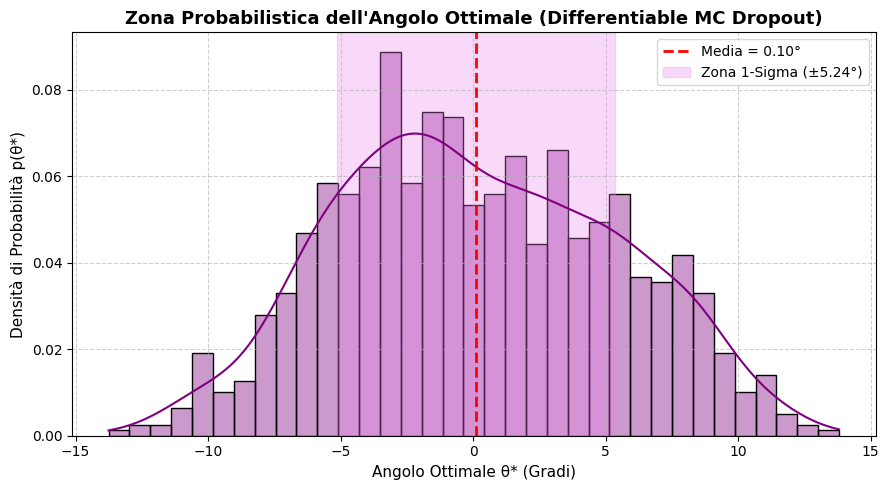

In [29]:
# ==============================================================================
# TASK 3: OTTIMIZZAZIONE ROBUSTA DIFFERENZIABILE (ZONA PROBABILISTICA VIA MC DROPOUT)
# ==============================================================================
print("\n" + "=" * 85)
print("   TASK 3: ESTIMATING PROBABILISTIC CONTINUOUS OPTIMAL ZONE (GRADIENT DESCENT)")
print("=" * 85)

n_runs_mc = 1000  # Numero di ottimizzazioni differenziabili indipendenti
angoli_ottimi_continui = []
losses_ottime = []

# Congeliamo i pesi della rete, MA teniamo il Dropout attivo!
for param in modello.parameters():
    param.requires_grad = False

# ATTENZIONE: modello.train() garantisce che il Dropout sia attivo durante la backprop!
modello.train()

# Parametri fisici costanti
PHI_RAD = 0.0
RAGGIO_MEDIO = float(X[:, 4].mean())

mean_X = torch.tensor(scaler_X.mean_, dtype=torch.float32, device=device)
scale_X = torch.tensor(scaler_X.scale_, dtype=torch.float32, device=device)
mean_y = torch.tensor(scaler_y.mean_, dtype=torch.float32, device=device)
scale_y = torch.tensor(scaler_y.scale_, dtype=torch.float32, device=device)

print(f"Esecuzione di {n_runs_mc} ottimizzazioni via Gradient Descent con perturbazioni MC Dropout...")

for run in range(n_runs_mc):
    # Inizializziamo ogni run in prossimità della zona promettente (es. 0° / 360°)
    theta_param = torch.tensor([np.radians(0.0)], dtype=torch.float32, device=device, requires_grad=True)
    optimizer_plaque = optim.Adam([theta_param], lr=0.03)

    # Breve ciclo di gradient descent per convergere sotto la maschera di dropout corrente
    for step in range(150):
        optimizer_plaque.zero_grad()

        sin_t, cos_t = torch.sin(theta_param), torch.cos(theta_param)
        sin_p = torch.tensor([np.sin(PHI_RAD)], dtype=torch.float32, device=device)
        cos_p = torch.tensor([np.cos(PHI_RAD)], dtype=torch.float32, device=device)
        r_val = torch.tensor([RAGGIO_MEDIO], dtype=torch.float32, device=device)

        x_input = torch.cat([sin_t, cos_t, sin_p, cos_p, r_val]).unsqueeze(0).float()
        x_input_scaled = (x_input - mean_X) / scale_X

        # Forward pass con Dropout attivo
        pred_scaled = modello(x_input_scaled)
        pred_log = (pred_scaled * scale_y) + mean_y
        pred_reale = torch.expm1(pred_log)

        loss, _ = calcola_loss_clinica(pred_reale)
        loss.backward()
        optimizer_plaque.step()

    # Salviamo l'angolo finale in gradi [0, 360)
    ang_deg = (np.degrees(theta_param.item()) % 360 + 360) % 360

    # Se l'angolo è vicinissimo a 360 (es. 359.8°), lo mappiamo a valori attorno allo 0 per continuità statistica
    if ang_deg > 180:
        ang_deg = ang_deg - 360.0

    angoli_ottimi_continui.append(ang_deg)
    losses_ottime.append(loss.item())

    if (run + 1) % 20 == 0:
        print(f"  └ Run [{run+1:3d}/{n_runs_mc}] completata...")

# Convertiamo in numpy array
angoli_ottimi_continui = np.array(angoli_ottimi_continui)

# --- ANALISI STATISTICA CONTINUA ---
media_angolo = np.mean(angoli_ottimi_continui)
std_angolo = np.std(angoli_ottimi_continui)

# Convertiamo la media riportandola nell'intervallo [0, 360)
media_angolo_deg = (media_angolo + 360) % 360

print("\n" + "*" * 85)
print(" 🎯 RISULTATI DELL'OTTIMIZZAZIONE PROBABILISTICA CONTINUA")
print("*" * 85)
print(f" Angolo Ottimale Medio (Mean θ*) : {media_angolo_deg:.2f}°")
print(f" Incertezza/Deviazione Standard (σ_θ): ±{std_angolo:.2f}°")
print(f" Zona d'Incertezza Clinica (95% CI): [{media_angolo_deg - 1.96*std_angolo:.2f}°, {media_angolo_deg + 1.96*std_angolo:.2f}°]")
print("*" * 85)

# ==============================================================================
# GRAFICO: STIMA DELLA DENSITÀ DI PROBABILITÀ (KDE / GAUSSIANA CONTINUA)
# ==============================================================================
plt.figure(figsize=(9, 5))

# Istogramma + Curva di Densità Continua (KDE)
sns.histplot(angoli_ottimi_continui, kde=True, color='purple', stat="density", bins=35, alpha=0.4)

plt.axvline(media_angolo, color='red', linestyle='--', linewidth=2, label=f'Media = {media_angolo_deg:.2f}°')
plt.axvspan(media_angolo - std_angolo, media_angolo + std_angolo, color='violet', alpha=0.3, label=f'Zona 1-Sigma (±{std_angolo:.2f}°)')

plt.title("Zona Probabilistica dell'Angolo Ottimale (Differentiable MC Dropout)", fontsize=13, fontweight='bold')
plt.xlabel("Angolo Ottimale θ* (Gradi)", fontsize=11)
plt.ylabel("Densità di Probabilità p(θ*)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig("probabilistic_continuous_optimal_zone.png", dpi=300)
plt.show()